# IOI Circuit — Post-Hoc Analysis

This notebook loads the **finalized binary-mask circuit** discovered by `ioi_llama_kl_budget.py`
and performs a set of interpretability analyses rooted in the circuit-discovery literature:

| Section | What it tells you |
|---------|-------------------|
| 1. Inventory | Which heads / MLP neurons survived pruning |
| 2. Attention patterns | Where surviving heads attend on IOI examples |
| 3. Head role classification | IO-Mover, S-Inhibitor, Duplicate-Token, … |
| 4. Direct Logit Attribution (DLA) | Which components push the model toward IO vs S |
| 5. OV circuit — unembedding projection | What each head promotes in vocabulary space |
| 6. Head ablation study | Which surviving heads are actually load-bearing |
| 7. Logit lens | How the IOI prediction builds up layer-by-layer |

**Literature references:**
- Wang et al. (2022) *Interpretability in the Wild: a Circuit for Indirect Object Identification in GPT-2 small*
- Elhage et al. (2021) *A Mathematical Framework for Transformer Circuits*
- Nostalgebraist (2020), Belrose et al. (2023) *Eliciting Latent Predictions from Transformers with the Tuned Lens*

In [1]:
import os, sys, pickle
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader

# ---- make project root importable ----
PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if not os.path.exists(os.path.join(PROJECT_ROOT, 'models')):
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from posthoc_analysis.analysis_utils import (
    load_circuit,
    get_surviving_heads,
    get_surviving_mlp_blocks,
    get_surviving_attn_blocks,
    get_surviving_mlp_neurons,
    circuit_summary_table,
    get_attention_patterns,
    compute_dla,
    dla_io_vs_s,
    compute_ov_top_tokens,
    ablate_head_and_eval,
    ablate_mlp_block_and_eval,
    compute_logit_lens,
    ioi_attention_scores,
    find_name_positions_batch,
    classify_head_role,
)
from dataset.ioi_llama import IOIDatasetLlama, run_evaluation

print('Imports OK')

Imports OK


## Configuration — set `SAVE_DIR` to your checkpoint folder

In [7]:
SAVE_DIR = '/home/exouser/circuit_pruning/results/ioi_kl_budget_final_1B_with_blocks_0.5kl_no_task_loss'   # <-- change if you used --save-dir
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 16      # reduce if OOM
N_ANALYSIS = 100     # samples for attention-pattern / DLA analysis (subset for speed)

print(f'Device: {DEVICE}  |  Save dir: {SAVE_DIR}')

Device: cuda  |  Save dir: /home/exouser/circuit_pruning/results/ioi_kl_budget_final_1B_with_blocks_0.5kl_no_task_loss


In [8]:
# Load models (this downloads nothing new — uses cached weights)
circuit_model, full_model, tokenizer, run_config = load_circuit(SAVE_DIR, device=DEVICE)

print(f"\nModel      : {run_config['model']}")
print(f"KL budget  : {run_config['kl_budget']}")
print(f"Circuit is in final binary-mask mode ✓")

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Llama model successfully adapted for pruning with block-level gates.
  Loaded 96 / 96 gates

--- Setting final circuit mode to: True ---
    Updated 112 HardConcreteGate modules.


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]


Model      : meta-llama/Llama-3.2-1B
KL budget  : 0.5
Circuit is in final binary-mask mode ✓


In [9]:
# Load test data
with open(os.path.join(SAVE_DIR, 'test_data.pkl'), 'rb') as f:
    test_data = pickle.load(f)

test_dataset    = IOIDatasetLlama(test_data, tokenizer)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Also load binary masks for quick gate inspection
binary_masks = torch.load(os.path.join(SAVE_DIR, 'binary_masks.pt'), map_location='cpu')

print(f'Test samples: {len(test_data)}')

Processed 996 valid samples from 996 total
Test samples: 996


---
## Section 1 — Circuit Inventory

How many heads / neurons survived the KL-budget pruning?  
This is the basic *what* before we ask *why*.

In [10]:
summary = circuit_summary_table(circuit_model)

n_total_heads  = circuit_model.config.num_attention_heads * len(circuit_model.model.layers)
n_surv_heads   = summary['n_heads'].sum()
n_surv_attn_blk = summary['attn_block'].sum()
n_surv_mlp_blk  = summary['mlp_block'].sum()
total_hid = circuit_model.config.intermediate_size * len(circuit_model.model.layers)
surv_hid  = summary['n_hid_neurons'].sum()

print(f"Attention heads  : {n_surv_heads:4d} / {n_total_heads}  ({n_surv_heads/n_total_heads*100:.1f}%)")
print(f"Attn blocks alive: {n_surv_attn_blk:4d} / {len(circuit_model.model.layers)}")
print(f"MLP  blocks alive: {n_surv_mlp_blk:4d} / {len(circuit_model.model.layers)}")
print(f"MLP hidden neurons: {surv_hid:6d} / {total_hid}  ({surv_hid/total_hid*100:.1f}%)")

# Display table
display(summary[['layer','attn_block','n_heads','head_pct','heads','mlp_block','n_hid_neurons','hid_pct']].to_string(index=False))

Attention heads  :   46 / 512  (9.0%)
Attn blocks alive:    6 / 16
MLP  blocks alive:    9 / 16
MLP hidden neurons:  22551 / 131072  (17.2%)


' layer  attn_block  n_heads  head_pct                                           heads  mlp_block  n_hid_neurons   hid_pct\n     0       False        0     0.000                                              []       True           5287 64.538574\n     1       False        0     0.000                                              []       True           2378 29.028320\n     2       False        0     0.000                                              []       True           1951 23.815918\n     3       False        0     0.000                                              []       True           1863 22.741699\n     4       False        0     0.000                                              []      False              0  0.000000\n     5       False        0     0.000                                              []      False              0  0.000000\n     6       False        0     0.000                                              []      False              0  0.000000\n     7       Fa

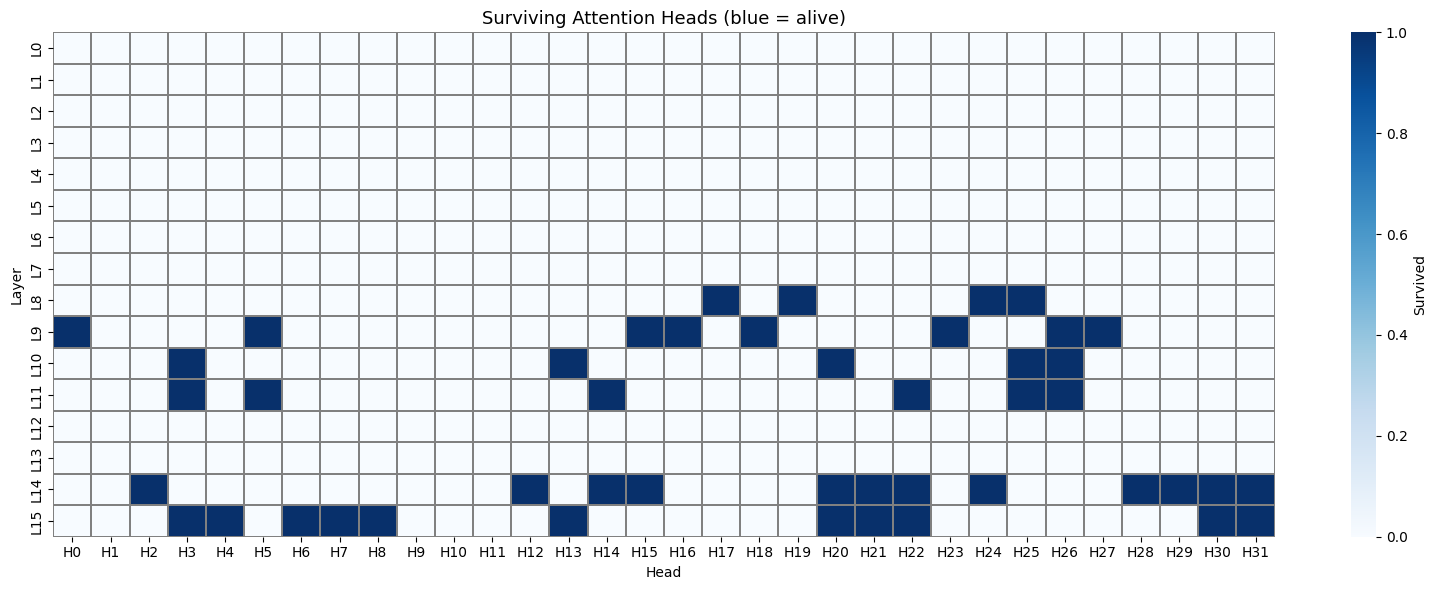

In [11]:
# Visual: surviving heads per layer (heatmap)
num_heads = circuit_model.config.num_attention_heads
n_layers  = len(circuit_model.model.layers)
surv_heads_dict = get_surviving_heads(circuit_model)

head_mask = np.zeros((n_layers, num_heads))
for l, heads in surv_heads_dict.items():
    for h in heads:
        head_mask[l, h] = 1.0

fig, ax = plt.subplots(figsize=(max(10, num_heads * 0.5), max(6, n_layers * 0.3)))
sns.heatmap(head_mask, ax=ax, cmap='Blues', vmin=0, vmax=1,
            linewidths=0.3, linecolor='grey',
            xticklabels=[f'H{h}' for h in range(num_heads)],
            yticklabels=[f'L{l}' for l in range(n_layers)],
            cbar_kws={'label': 'Survived'})
ax.set_title('Surviving Attention Heads (blue = alive)', fontsize=13)
ax.set_xlabel('Head'); ax.set_ylabel('Layer')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'posthoc_head_mask.png'), dpi=150)
plt.show()

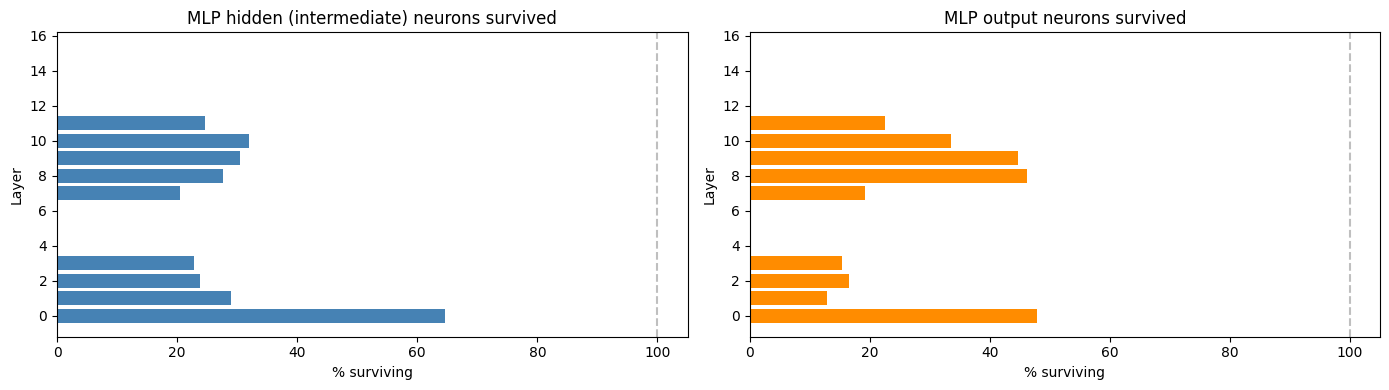

In [12]:
# Visual: surviving MLP hidden neurons per layer
surv_neurons = get_surviving_mlp_neurons(circuit_model)
layers_axis  = list(range(n_layers))
hid_pcts     = [len(surv_neurons[l][0]) / circuit_model.config.intermediate_size * 100 for l in layers_axis]
out_pcts     = [len(surv_neurons[l][1]) / circuit_model.config.hidden_size * 100 for l in layers_axis]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(layers_axis, hid_pcts, color='steelblue')
axes[0].set_xlabel('% surviving'); axes[0].set_ylabel('Layer')
axes[0].set_title('MLP hidden (intermediate) neurons survived')
axes[0].axvline(100, color='grey', linestyle='--', alpha=0.5)

axes[1].barh(layers_axis, out_pcts, color='darkorange')
axes[1].set_xlabel('% surviving'); axes[1].set_ylabel('Layer')
axes[1].set_title('MLP output neurons survived')
axes[1].axvline(100, color='grey', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'posthoc_mlp_neurons.png'), dpi=150)
plt.show()

---
## Section 2 — Attention Patterns on IOI Examples

We compute **approximate** attention patterns by hooking the Q and K projections
and computing Q·Kᵀ / √d without RoPE (qualitatively accurate for position classification).

For each surviving head we look at the attention row **from the prediction position** to see
whether the head attends to the IO name, the S name, or elsewhere.

Wang et al. (2022) found in GPT-2:
- **Name Mover Heads**: attend to IO at prediction time → copy IO token  
- **S-Inhibition Heads**: attend to S₂ (end of sentence) → suppress S  
- **Duplicate Token Heads**: attend to the first occurrence of the repeated token

In [13]:
# Grab the first N_ANALYSIS test examples
analysis_batch = next(iter(DataLoader(test_dataset, batch_size=N_ANALYSIS, shuffle=False)))

# ---- Prediction position ----
# T_Start = 0-indexed position of the answer token in input_ids.
# Llama always prepends BOS at position 0, so T_Start >= 1.
# We read logits at T_Start - 1 to predict token at T_Start.
pred_pos = analysis_batch['T_Start'] - 1    # (B,)  0-indexed

# ---- Find IO and S name positions by searching actual token IDs ----
# target_tokens[b,0]     = token ID for " IOname" (space-prefixed, as it appears mid-sentence)
# distractor_tokens[b,0] = token ID for " Sname"
# Search in input_ids[b, 1 : T_Start[b]]  — skip BOS at 0, stop before answer
target_tok_ids     = analysis_batch['target_tokens'][:, 0]
distractor_tok_ids = analysis_batch['distractor_tokens'][:, 0]
answer_positions   = analysis_batch['T_Start']   # (B,) 0-indexed position of answer token

io_positions_list = find_name_positions_batch(
    analysis_batch['input_ids'], target_tok_ids, answer_positions
)  # list[list[int]] — IO name position(s) in sentence body

s_positions_list = find_name_positions_batch(
    analysis_batch['input_ids'], distractor_tok_ids, answer_positions
)  # list[list[int]] — S name positions (should be 2 per sample: subject + agent)

# Sanity check
io_counts = [len(p) for p in io_positions_list]
s_counts  = [len(p) for p in s_positions_list]
print(f'IO body occurrences: min={min(io_counts)}  max={max(io_counts)}  mean={sum(io_counts)/len(io_counts):.2f}')
print(f'S  body occurrences: min={min(s_counts)}   max={max(s_counts)}   mean={sum(s_counts)/len(s_counts):.2f}')
print(f'Ex 0: pred_pos={pred_pos[0].item()}  IO={io_positions_list[0]}  S={s_positions_list[0]}')
print(f'      Sentence: {tokenizer.decode(analysis_batch["input_ids"][0].tolist(), skip_special_tokens=False)[:120]}')

# Convert to tensors — use last IO body occurrence, first/last S occurrence
B = len(io_positions_list)
io_pos = torch.tensor([ps[-1] if ps else pred_pos[b].item()-1 for b, ps in enumerate(io_positions_list)])
s1_pos = torch.tensor([ps[0]  if ps else 1 for ps in s_positions_list])
s2_pos = torch.tensor([ps[-1] if ps else 1 for ps in s_positions_list])

print(f'\nComputing attention patterns for {N_ANALYSIS} examples ...')
attn_patterns = get_attention_patterns(
    circuit_model,
    analysis_batch['input_ids'],
    analysis_batch['attention_mask'],
    analysis_batch['corrupted_input_ids'],   # actual name-swapped corrupted inputs
    device=DEVICE,
)
print(f'Done. Patterns computed for {len(attn_patterns)} layers.')

IO body occurrences: min=1  max=1  mean=1.00
S  body occurrences: min=2   max=2   mean=2.00
Ex 0: pred_pos=15  IO=[4]  S=[2, 12]
      Sentence: <|begin_of_text|>Friends Rebecca and Marshall found a phone at the zoo. Rebecca gave it to Marshall<|end_of_text|><|end_

Computing attention patterns for 100 examples ...
Done. Patterns computed for 16 layers.


In [14]:
# Compute IOI-specific attention scores at prediction position
seq_len = analysis_batch['input_ids'].shape[1]
attn_scores = ioi_attention_scores(
    attn_patterns,
    pred_positions=pred_pos,
    io_positions=io_pos,
    s_positions=[s1_pos, s2_pos],
    seq_len=seq_len,
)   # {layer: (B, H, 4)}  dim-2: [io, s1, s2, other]

# Mean over batch
mean_attn_scores = {l: v.mean(0).numpy() for l, v in attn_scores.items()}  # {layer: (H, 4)}

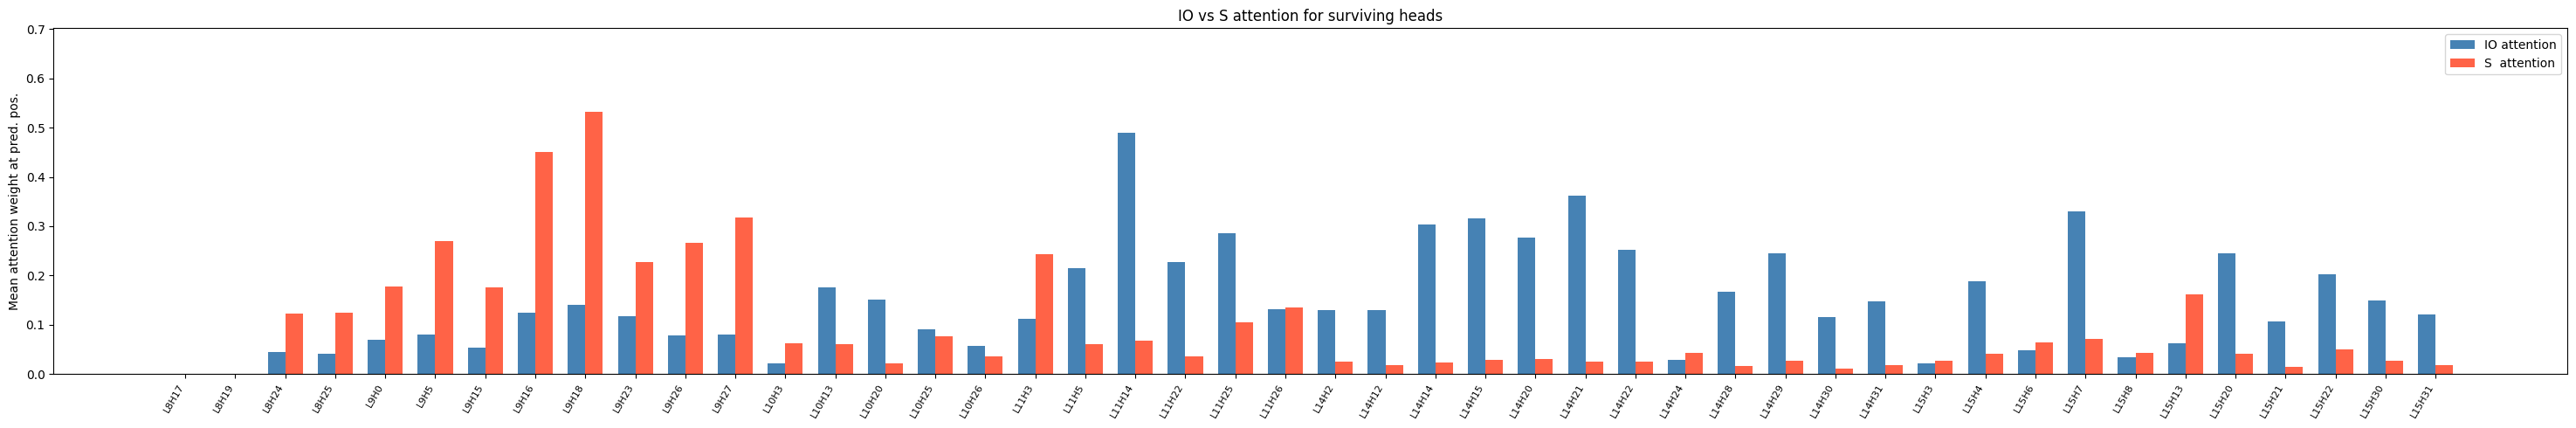

In [15]:
# Plot: per surviving head — IO vs S attention score
surviving_heads_dict = get_surviving_heads(circuit_model)
surv_head_list = [(l, h) for l, heads in sorted(surviving_heads_dict.items()) for h in heads]

if not surv_head_list:
    print('No surviving heads to plot.')
else:
    io_scores  = []
    s_scores   = []   # s1 + s2
    head_labels = []

    for (l, h) in surv_head_list:
        if l in mean_attn_scores:
            scores = mean_attn_scores[l][h]    # [io, s1, s2, other]
            io_scores.append(scores[0])
            s_scores.append(scores[1] + scores[2])   # total S attention
            head_labels.append(f'L{l}H{h}')

    io_arr = np.array(io_scores)
    s_arr  = np.array(s_scores)

    fig, ax = plt.subplots(figsize=(max(8, len(head_labels) * 0.6 + 2), 5))
    x = np.arange(len(head_labels))
    w = 0.35
    ax.bar(x - w/2, io_arr, w, label='IO attention', color='steelblue')
    ax.bar(x + w/2, s_arr,  w, label='S  attention', color='tomato')
    ax.set_xticks(x)
    ax.set_xticklabels(head_labels, rotation=60, ha='right', fontsize=8)
    ax.set_ylabel('Mean attention weight at pred. pos.')
    ax.set_title('IO vs S attention for surviving heads')
    ax.legend()
    ax.set_ylim(0, max(max(io_arr), max(s_arr)) * 1.3 + 0.01)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'posthoc_attn_io_vs_s.png'), dpi=150)
    plt.show()

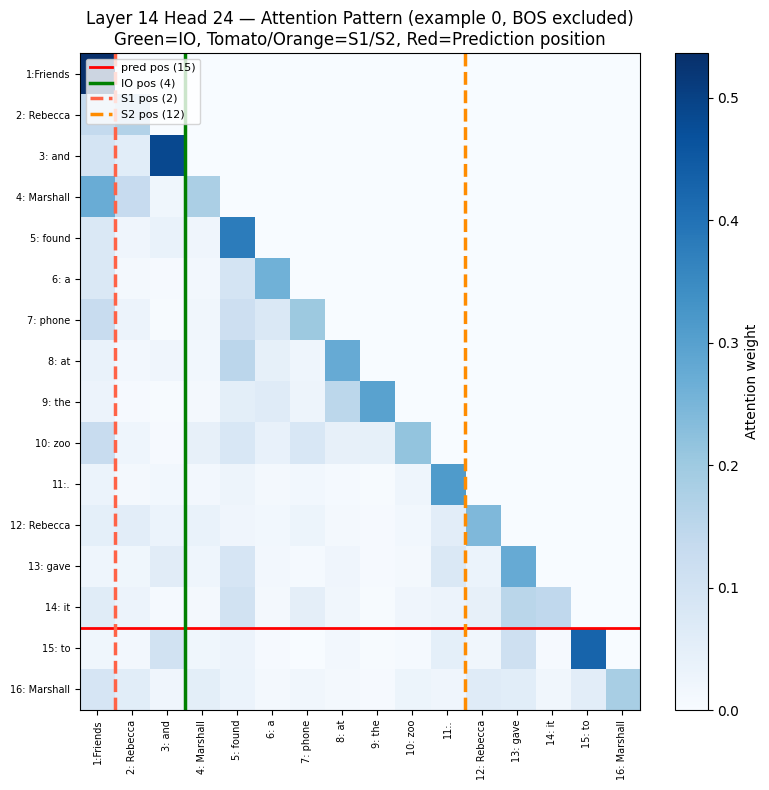


Attention weights from pred_pos (15) → name positions (example 0):
  → IO  (pos 4,  'Marshall'): 0.0199
  → S1  (pos 2,  'Rebecca'): 0.0130
  → S2  (pos 12,  'Rebecca'): 0.0186


In [16]:
# For a specific head of interest, plot the full attention pattern focused on IO and S positions
# Change these to any (layer, head) from surv_head_list:
VIZ_LAYER, VIZ_HEAD = surv_head_list[30] if surv_head_list else (0, 0)

if VIZ_LAYER in attn_patterns:
    eg_idx  = 0
    pattern = attn_patterns[VIZ_LAYER][eg_idx, VIZ_HEAD].numpy()   # (S, S)
    valid   = int(analysis_batch['attention_mask'][eg_idx].sum().item())

    # Exclude BOS token (position 0) — most attention mass pools there
    pattern_valid = pattern[1:valid, 1:valid]

    tokens = [tokenizer.decode([t]) for t in analysis_batch['input_ids'][eg_idx, 1:valid].tolist()]
    pred_p = pred_pos[eg_idx].item()
    io_p   = io_pos[eg_idx].item()
    s1_p   = s1_pos[eg_idx].item()
    s2_p   = s2_pos[eg_idx].item()
    n = valid - 1  # number of tokens after removing BOS

    fig, ax = plt.subplots(figsize=(min(n, 30) * 0.5, min(n, 30) * 0.5))
    im = ax.imshow(pattern_valid, cmap='Blues', vmin=0, aspect='auto')
    tick_labels = [f'{i+1}:{t}' for i, t in enumerate(tokens)]
    ax.set_xticks(range(n)); ax.set_xticklabels(tick_labels, rotation=90, fontsize=7)
    ax.set_yticks(range(n)); ax.set_yticklabels(tick_labels, fontsize=7)
    # Shift positions by -1 to account for removed BOS
    ax.axhline((pred_p - 1) - 0.5, color='red',        linewidth=2, label=f'pred pos ({pred_p})')
    ax.axvline((io_p   - 1) - 0.5, color='green',      linewidth=2.5, label=f'IO pos ({io_p})')
    ax.axvline((s1_p   - 1) - 0.5, color='tomato',     linewidth=2.5, linestyle='--', label=f'S1 pos ({s1_p})')
    ax.axvline((s2_p   - 1) - 0.5, color='darkorange', linewidth=2.5, linestyle='--', label=f'S2 pos ({s2_p})')
    plt.colorbar(im, ax=ax, label='Attention weight')
    ax.set_title(
        f'Layer {VIZ_LAYER} Head {VIZ_HEAD} — Attention Pattern (example {eg_idx}, BOS excluded)\n'
        f'Green=IO, Tomato/Orange=S1/S2, Red=Prediction position'
    )
    ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'posthoc_attn_pattern_L{VIZ_LAYER}H{VIZ_HEAD}.png'), dpi=150)
    plt.show()

    # Print attention from prediction position → IO and S token positions
    pred_row = pattern_valid[pred_p - 1]   # row = pred pos (adjusted for removed BOS)
    print(f"\nAttention weights from pred_pos ({pred_p}) → name positions (example {eg_idx}):")
    print(f"  → IO  (pos {io_p},  '{tokenizer.decode([analysis_batch['input_ids'][eg_idx, io_p].item()]).strip()}'): {pred_row[io_p - 1]:.4f}")
    print(f"  → S1  (pos {s1_p},  '{tokenizer.decode([analysis_batch['input_ids'][eg_idx, s1_p].item()]).strip()}'): {pred_row[s1_p - 1]:.4f}")
    print(f"  → S2  (pos {s2_p},  '{tokenizer.decode([analysis_batch['input_ids'][eg_idx, s2_p].item()]).strip()}'): {pred_row[s2_p - 1]:.4f}")


---
## Section 3 — Direct Logit Attribution (DLA)

DLA decomposes the final logit into contributions from each component:
$$\text{logit}(t) = W_U \cdot \text{LN}\left(\sum_c v_c\right) \approx \sum_c W_U \cdot \hat{\text{LN}}(v_c)$$

where $\hat{\text{LN}}$ is the **frozen-scale** linearization (scale computed on the
actual residual, applied independently to each component).  
This is the standard TransformerLens DLA approach (Elhage 2021, Wang 2022).

We look at the **IO score − S score** per component: positive = pushes model toward correct answer.

In [17]:
print('Computing DLA (this runs one forward pass with hooks) ...')
dla_result = compute_dla(
    circuit_model,
    analysis_batch['input_ids'],
    analysis_batch['attention_mask'],
    analysis_batch['corrupted_input_ids'],   # actual corrupted inputs
    pred_positions=pred_pos,
    device=DEVICE,
)
print('DLA done.')

# Gather target and distractor token IDs
target_ids     = analysis_batch['target_tokens'][:, 0]      # (B,)
distractor_ids = analysis_batch['distractor_tokens'][:, 0]  # (B,)

Computing DLA (this runs one forward pass with hooks) ...
DLA done.


In [18]:
# Per-head: mean (IO DLA - S DLA) across batch — positive = good for task
head_dla_diff = {}   # {(layer, head): float}

for l, attn_dla in dla_result['attn'].items():
    # attn_dla: (B, H, vocab)
    io_s, s_s = dla_io_vs_s(attn_dla, target_ids, distractor_ids)
    # io_s, s_s: (B, H)
    diff = (io_s - s_s).mean(0).numpy()    # (H,)
    for h in range(diff.shape[0]):
        head_dla_diff[(l, h)] = diff[h]

# Per-MLP-layer: mean (IO DLA - S DLA)
mlp_dla_diff = {}
for l, mlp_dla in dla_result['mlp'].items():
    io_s, s_s = dla_io_vs_s(mlp_dla, target_ids, distractor_ids)
    mlp_dla_diff[l] = (io_s - s_s).mean().item()

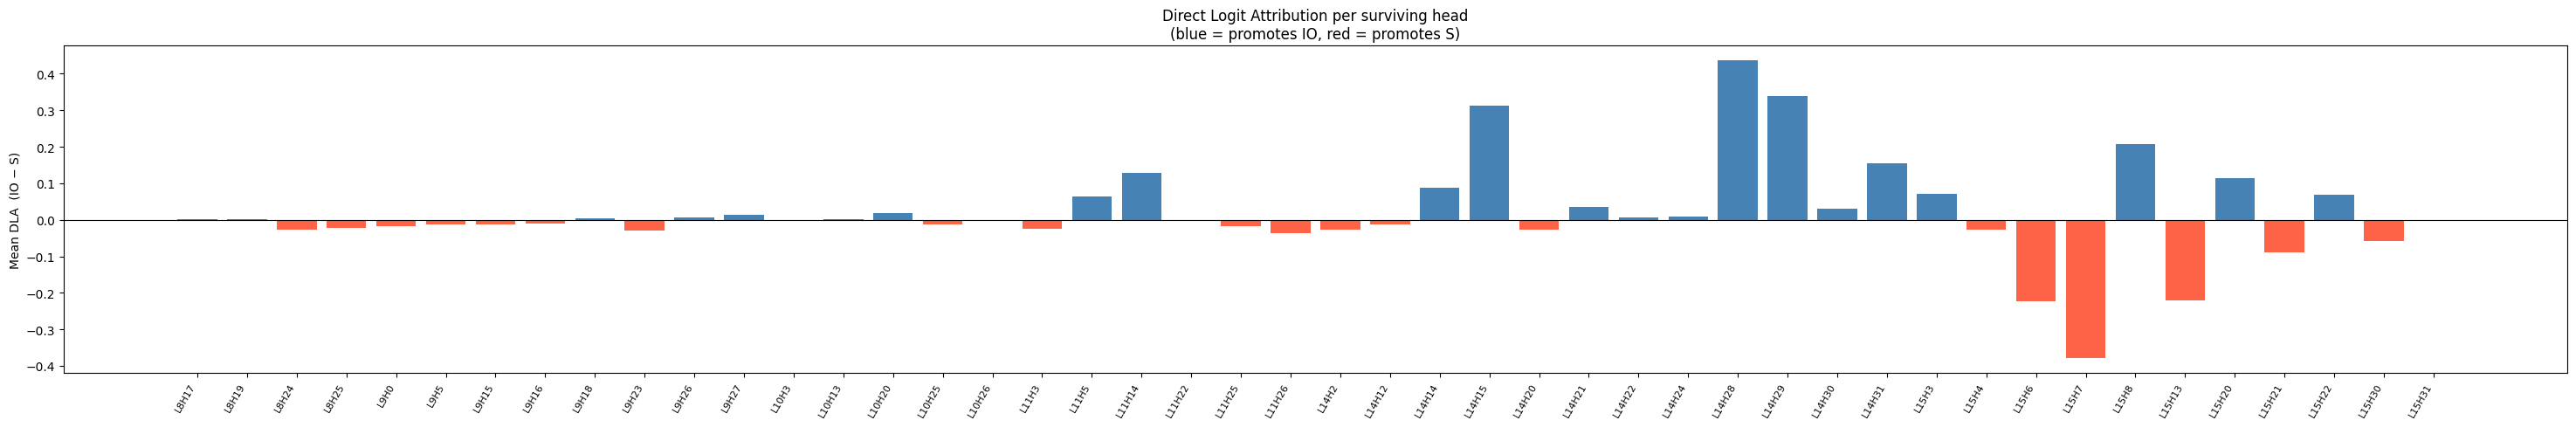

Embedding DLA (IO - S): 0.0087


In [19]:
# Plot DLA for surviving heads
if surv_head_list:
    dla_vals   = [head_dla_diff.get((l, h), 0.0) for (l, h) in surv_head_list]
    colors = ['steelblue' if v >= 0 else 'tomato' for v in dla_vals]

    fig, ax = plt.subplots(figsize=(max(8, len(surv_head_list) * 0.6 + 2), 5))
    x = np.arange(len(surv_head_list))
    ax.bar(x, dla_vals, color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'L{l}H{h}' for (l,h) in surv_head_list], rotation=60, ha='right', fontsize=8)
    ax.set_ylabel('Mean DLA  (IO − S)')
    ax.set_title('Direct Logit Attribution per surviving head\n(blue = promotes IO, red = promotes S)')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'posthoc_dla_heads.png'), dpi=150)
    plt.show()

# Embed contribution
if dla_result['embed'] is not None:
    io_e, s_e = dla_io_vs_s(dla_result['embed'], target_ids, distractor_ids)
    print(f'Embedding DLA (IO - S): {(io_e - s_e).mean().item():.4f}')

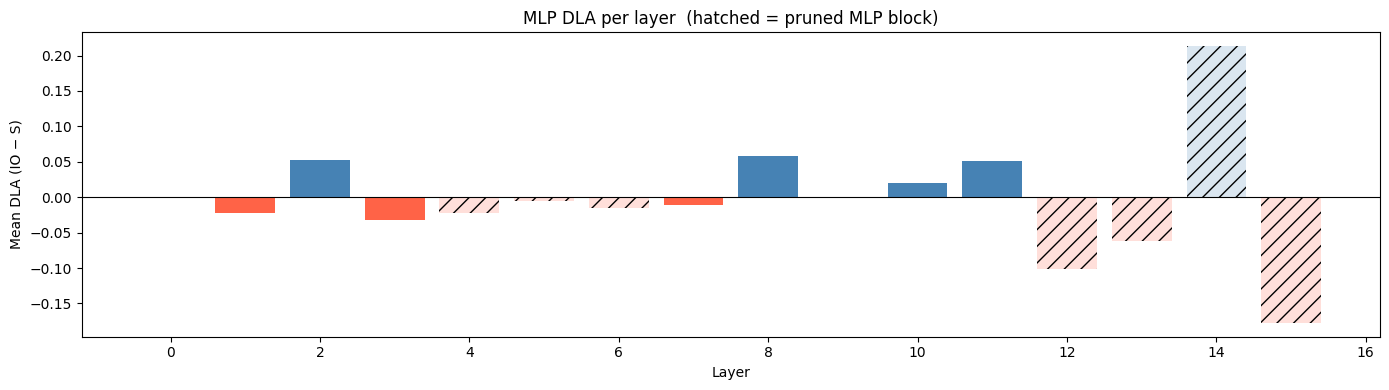

In [20]:
# Plot MLP DLA per layer
if mlp_dla_diff:
    ls_mlp = sorted(mlp_dla_diff.keys())
    vals   = [mlp_dla_diff[l] for l in ls_mlp]
    surv_mlp = get_surviving_mlp_blocks(circuit_model)

    fig, ax = plt.subplots(figsize=(14, 4))
    colors = ['steelblue' if v >= 0 else 'tomato' for v in vals]
    bars = ax.bar(ls_mlp, vals, color=colors)
    # Mark dead MLP blocks
    for l, bar in zip(ls_mlp, bars):
        if not surv_mlp.get(l, True):
            bar.set_alpha(0.2)
            bar.set_hatch('//')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Layer'); ax.set_ylabel('Mean DLA (IO − S)')
    ax.set_title('MLP DLA per layer  (hatched = pruned MLP block)')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'posthoc_dla_mlp.png'), dpi=150)
    plt.show()

---
## Section 4 — Head Role Classification

Combining attention patterns (where a head looks) and DLA (what it contributes),
we classify each surviving head into one of the roles from Wang et al. (2022):

| Role | Attention | DLA (IO−S) |
|------|-----------|-------------|
| **IO-Mover** (NMH) | High IO | Positive |
| **Neg-IO-Mover** | High IO | Negative |
| **S-Inhibitor** | High S | S DLA < 0 |
| **S-Promoter** | High S | S DLA > 0 |
| **Other** | — | — |

In [21]:
role_rows = []
for (l, h) in surv_head_list:
    io_attn = float(mean_attn_scores[l][h, 0])          if l in mean_attn_scores else 0.0
    s_attn  = float(mean_attn_scores[l][h, 1] +
                    mean_attn_scores[l][h, 2])           if l in mean_attn_scores else 0.0

    # DLA for this specific head
    if l in dla_result['attn']:
        attn_dla = dla_result['attn'][l]    # (B, H, vocab)
        io_d = attn_dla[:, h, target_ids].diagonal().mean().item()
        s_d  = attn_dla[:, h, distractor_ids].diagonal().mean().item()
    else:
        io_d, s_d = 0.0, 0.0

    role = classify_head_role(io_attn, s_attn, io_d, s_d)
    role_rows.append({
        'layer': l, 'head': h, 'label': f'L{l}H{h}',
        'io_attn': round(io_attn, 4), 's_attn': round(s_attn, 4),
        'io_dla': round(io_d, 3), 's_dla': round(s_d, 3),
        'io_dla_minus_s_dla': round(io_d - s_d, 3),
        'role': role,
    })

role_df = pd.DataFrame(role_rows)
print(role_df[['label','io_attn','s_attn','io_dla','s_dla','io_dla_minus_s_dla','role']].to_string(index=False))

 label  io_attn  s_attn  io_dla  s_dla  io_dla_minus_s_dla         role
 L8H17   0.0004  0.0005  -0.006 -0.006               0.001  S-Inhibitor
 L8H19   0.0000  0.0000  -0.007 -0.009               0.002  S-Inhibitor
 L8H24   0.0436  0.1232   0.007  0.035              -0.028   S-Promoter
 L8H25   0.0401  0.1249   0.009  0.030              -0.021   S-Promoter
  L9H0   0.0688  0.1778  -0.010  0.007              -0.017   S-Promoter
  L9H5   0.0807  0.2703  -0.005  0.007              -0.012   S-Promoter
 L9H15   0.0535  0.1752   0.004  0.015              -0.012   S-Promoter
 L9H16   0.1248  0.4513   0.020  0.031              -0.011   S-Promoter
 L9H18   0.1401  0.5323  -0.006 -0.010               0.004  S-Inhibitor
 L9H23   0.1177  0.2268   0.009  0.039              -0.030   S-Promoter
 L9H26   0.0775  0.2666   0.005 -0.001               0.006  S-Inhibitor
 L9H27   0.0797  0.3170  -0.019 -0.032               0.013  S-Inhibitor
 L10H3   0.0222  0.0630   0.007  0.011              -0.004   S-P

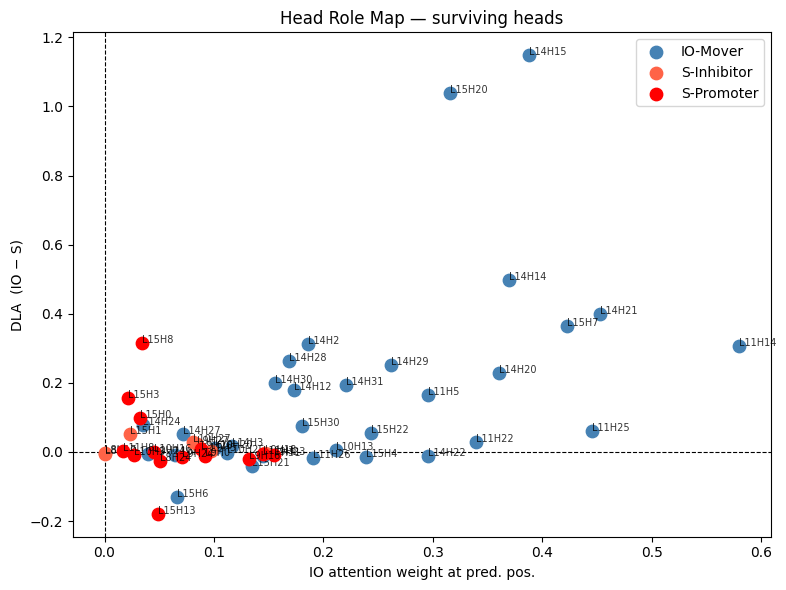


Role breakdown:
role
IO-Mover       32
S-Promoter     14
S-Inhibitor     7


In [55]:
# Scatter plot: IO attention vs DLA(IO-S) — color-coded by role
role_colors = {
    'IO-Mover': 'steelblue', 'Neg-IO-Mover': 'navy',
    'S-Inhibitor': 'tomato', 'S-Promoter': 'red', 'Other': 'grey'
}

fig, ax = plt.subplots(figsize=(8, 6))
for role, grp in role_df.groupby('role'):
    ax.scatter(grp['io_attn'], grp['io_dla_minus_s_dla'],
               label=role, color=role_colors.get(role, 'grey'), s=80, zorder=3)
    for _, row in grp.iterrows():
        ax.annotate(row['label'], (row['io_attn'], row['io_dla_minus_s_dla']),
                    fontsize=7, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('IO attention weight at pred. pos.')
ax.set_ylabel('DLA  (IO − S)')
ax.set_title('Head Role Map — surviving heads')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'posthoc_role_map.png'), dpi=150)
plt.show()

print('\nRole breakdown:')
print(role_df['role'].value_counts().to_string())

---
## Section 5 — OV Circuit: Unembedding Projection

The OV circuit (Elhage et al. 2021) asks: *given that a head attends to token t, what does it write into the residual stream?*

$$W_{OV}^{(h)} = W_O^{(h)} W_V^{(h)}$$

We then project: $W_U W_{OV}^{(h)} W_E$ — the full token-to-token copying map.  
A high diagonal entry means head h tends to **copy** the token it attends to.  
We also look at what tokens the head promotes **on average** (the mean output direction).

This is the weight-space analysis — no forward pass needed.

In [18]:
ov_rows = []
for (l, h) in tqdm(surv_head_list, desc='OV analysis'):
    top_copy, top_prom, top_supp, copy_score = compute_ov_top_tokens(
        circuit_model, l, h, tokenizer, top_k=10
    )

    # ---- IO/S-specific OV write-logits ----
    # When head attends to IO token: does its output boost IO? (IO-mover signal)
    # When head attends to S  token: does its output suppress S? (S-inhibitor signal)
    attn_mod  = circuit_model.model.layers[l].attn.original_attention
    head_dim  = circuit_model.config.hidden_size // circuit_model.config.num_attention_heads
    kv_groups = circuit_model.config.num_attention_heads // circuit_model.config.num_key_value_heads
    kv_head   = h // kv_groups

    W_V_h  = attn_mod.v_proj.weight[kv_head * head_dim : (kv_head + 1) * head_dim, :].detach().float().cpu()
    W_O_h  = attn_mod.o_proj.weight[:, h * head_dim : (h + 1) * head_dim].detach().float().cpu()
    W_E_ov = circuit_model.model.embed_tokens.weight.detach().float().cpu()
    W_U_ov = circuit_model.lm_head.weight.detach().float().cpu()
    W_OV   = W_O_h @ W_V_h        # (hidden, hidden)
    W_U_OV = W_U_ov @ W_OV        # (vocab, hidden)  — row r = what token r gets written

    # io_copy_score: attend to IO token → logit boost for IO token  (want high for IO-Movers)
    io_copy = torch.stack([
        (W_U_OV[target_ids[b].item()] * W_E_ov[target_ids[b].item()]).sum()
        for b in range(len(target_ids))
    ]).mean().item()

    # s_copy_score: attend to S token → logit boost for S token  (want negative for S-Inhibitors)
    s_copy = torch.stack([
        (W_U_OV[distractor_ids[b].item()] * W_E_ov[distractor_ids[b].item()]).sum()
        for b in range(len(distractor_ids))
    ]).mean().item()

    ov_rows.append({
        'label': f'L{l}H{h}', 'layer': l, 'head': h,
        'io_copy_score':    round(io_copy, 4),
        's_copy_score':     round(s_copy,  4),
        'io_minus_s_copy':  round(io_copy - s_copy, 4),
        'general_copy_score': round(copy_score, 4),
        'top_copy_tokens':  top_copy[:5],
        'top_promoted':     top_prom[:5],
        'top_suppressed':   top_supp[:5],
    })

ov_df = pd.DataFrame(ov_rows).sort_values('io_minus_s_copy', ascending=False)
print('\nOV Circuit — IO vs S token copying (sorted by IO−S copy score):')
print('  io_copy_score  : head attends to IO token → how much it boosts IO logit (↑ = IO-Mover)')
print('  s_copy_score   : head attends to S  token → how much it boosts S  logit (↓ = S-Inhibitor)')
print('  io_minus_s_copy: net IO advantage (↑ = task-helpful)\n')
print(ov_df[['label', 'io_copy_score', 's_copy_score', 'io_minus_s_copy', 'general_copy_score']].to_string(index=False))


OV analysis:   0%|          | 0/50 [00:00<?, ?it/s]


OV Circuit — IO vs S token copying (sorted by IO−S copy score):
  io_copy_score  : head attends to IO token → how much it boosts IO logit (↑ = IO-Mover)
  s_copy_score   : head attends to S  token → how much it boosts S  logit (↓ = S-Inhibitor)
  io_minus_s_copy: net IO advantage (↑ = task-helpful)

 label  io_copy_score  s_copy_score  io_minus_s_copy  general_copy_score
 L15H8         0.0446        0.0418           0.0028              8.7072
L15H31         0.0025        0.0012           0.0013              0.9592
L15H30        -0.0007       -0.0019           0.0012              0.1200
 L14H3         0.0023        0.0016           0.0007              0.6660
L14H31         0.0035        0.0029           0.0007              0.5907
 L15H3         0.0152        0.0146           0.0007              2.3925
L11H22         0.0064        0.0059           0.0005              4.1682
  L9H0         0.0094        0.0091           0.0004              6.9463
 L8H19         0.0027        0.0024      

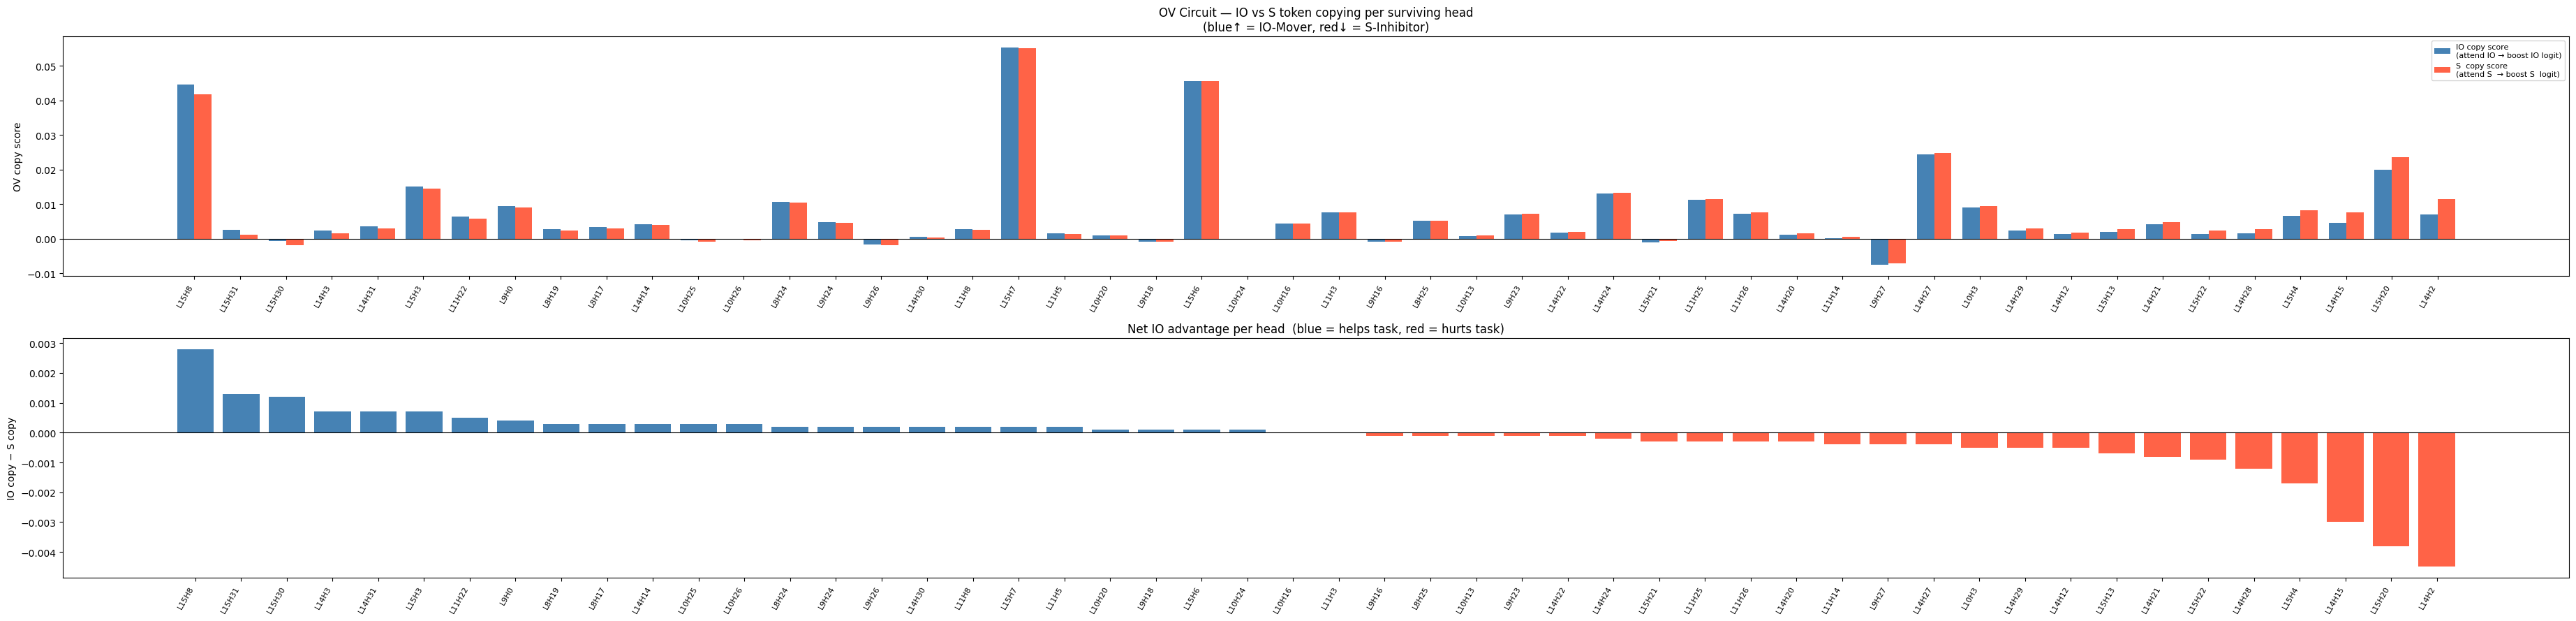

In [19]:
# Grouped bar chart: IO copy score vs S copy score per head, sorted by IO−S
ov_sorted = ov_df.sort_values('io_minus_s_copy', ascending=False)
labels = ov_sorted['label'].values
io_cs  = ov_sorted['io_copy_score'].values
s_cs   = ov_sorted['s_copy_score'].values
diff_cs = ov_sorted['io_minus_s_copy'].values

fig, axes = plt.subplots(2, 1, figsize=(max(10, len(labels) * 0.7 + 2), 9))

# Top panel: IO and S copy scores side-by-side
x = np.arange(len(labels))
w = 0.38
axes[0].bar(x - w/2, io_cs, w, label='IO copy score\n(attend IO → boost IO logit)', color='steelblue')
axes[0].bar(x + w/2, s_cs,  w, label='S  copy score\n(attend S  → boost S  logit)',  color='tomato')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=60, ha='right', fontsize=8)
axes[0].set_ylabel('OV copy score')
axes[0].set_title('OV Circuit — IO vs S token copying per surviving head\n'
                  '(blue↑ = IO-Mover, red↓ = S-Inhibitor)')
axes[0].legend(fontsize=8)

# Bottom panel: IO − S copy score (net task signal)
colors_diff = ['steelblue' if v >= 0 else 'tomato' for v in diff_cs]
axes[1].bar(x, diff_cs, color=colors_diff)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=60, ha='right', fontsize=8)
axes[1].set_ylabel('IO copy − S copy')
axes[1].set_title('Net IO advantage per head  (blue = helps task, red = hurts task)')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'posthoc_ov_io_vs_s.png'), dpi=150)
plt.show()


---
## Section 6 — Head Ablation Study

For each surviving head, zero its gate and re-run the test set.  
The accuracy **drop** tells us how load-bearing each head is.

This is different from the pruning criterion (KL budget): the pruning
optimised faithfulness to the full model; here we measure direct task impact.

In [56]:
# Baseline accuracy with the full circuit
baseline_res = run_evaluation(
    model_to_eval=circuit_model,
    model_name='Circuit-baseline',
    full_model_for_faithfulness=None,
    dataloader=test_dataloader,
    device=DEVICE,
    verbose=False,
    tokenizer=tokenizer,
)
baseline_acc = baseline_res['accuracy']
print(f'Circuit baseline accuracy: {baseline_acc:.4f}')

Circuit baseline accuracy: 0.9829


In [57]:
# Ablate each surviving head and record accuracy
# WARNING: this runs one forward pass per head — can be slow for many heads
ablation_rows = []
for (l, h) in tqdm(surv_head_list, desc='Ablating heads'):
    acc = ablate_head_and_eval(circuit_model, l, h, test_dataloader, DEVICE)
    ablation_rows.append({
        'label': f'L{l}H{h}', 'layer': l, 'head': h,
        'acc_ablated': acc,
        'acc_drop': baseline_acc - acc,
    })
    print(f'  L{l}H{h}: {acc:.4f}  (drop {baseline_acc - acc:+.4f})')

abl_df = pd.DataFrame(ablation_rows).sort_values('acc_drop', ascending=False)
print('\nMost critical heads:')
print(abl_df.head(10).to_string(index=False))

Ablating heads:   0%|          | 0/53 [00:00<?, ?it/s]

  L8H17: 0.9066  (drop +0.0763)


  L8H19: 0.9578  (drop +0.0251)


  L8H24: 0.9829  (drop +0.0000)


  L9H0: 0.9829  (drop +0.0000)


...

  L10H16: 0.9829  (drop +0.0000)


  L10H20: 0.9829  (drop +0.0000)


  L10H24: 0.9849  (drop -0.0020)


  L10H25: 0.9829  (drop +0.0000)


KeyboardInterrupt: 

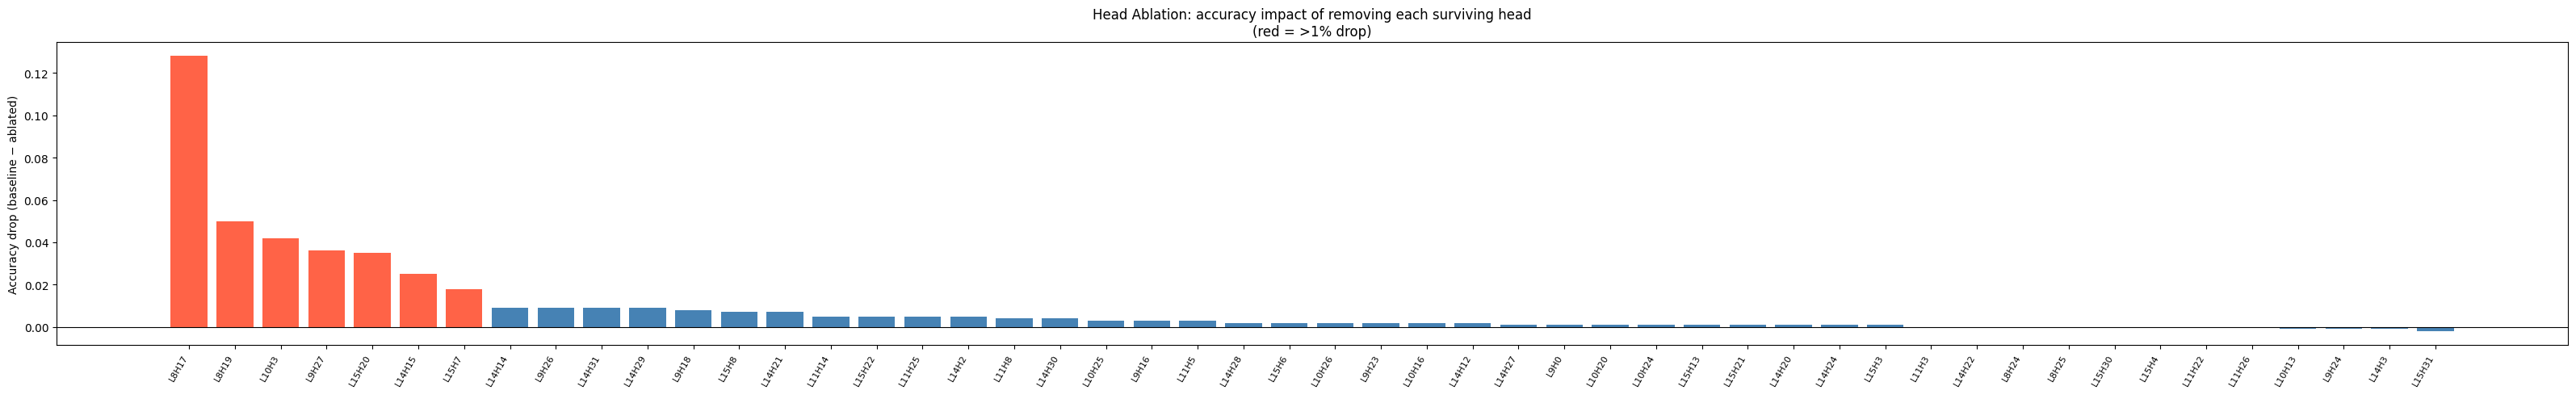

In [22]:
# Bar chart: accuracy drop per head
fig, ax = plt.subplots(figsize=(max(8, len(abl_df) * 0.6 + 2), 5))
colors = ['tomato' if v > 0.01 else 'steelblue' for v in abl_df['acc_drop'].values]
ax.bar(range(len(abl_df)), abl_df['acc_drop'].values, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(abl_df)))
ax.set_xticklabels(abl_df['label'].values, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Accuracy drop (baseline − ablated)')
ax.set_title('Head Ablation: accuracy impact of removing each surviving head\n(red = >1% drop)')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'posthoc_ablation.png'), dpi=150)
plt.show()

In [ ]:
# Merge all head-level info into one summary table
if not role_df.empty and not abl_df.empty and not ov_df.empty:
    merged = role_df.merge(abl_df[['label','acc_ablated','acc_drop']], on='label', how='left')
    merged = merged.merge(ov_df[['label','copying_score','top_promoted']], on='label', how='left')
    cols   = ['label','role','io_attn','s_attn','io_dla_minus_s_dla',
               'copying_score','acc_drop','top_promoted']
    print('\n=== Full Head Summary ===')
    print(merged[cols].sort_values('acc_drop', ascending=False).to_string(index=False))
    merged.to_csv(os.path.join(SAVE_DIR, 'posthoc_head_summary.csv'), index=False)
    print(f'\nSaved -> {SAVE_DIR}/posthoc_head_summary.csv')

---
## Section 7 — Logit Lens

Apply the final LayerNorm + unembedding to the residual stream at every layer.
This shows how the model's prediction *evolves* through the discovered circuit.

Based on Nostalgebraist (2020) / Belrose et al. (2023).

In [58]:
print('Computing logit lens ...')
N_LENS = min(32, N_ANALYSIS)
lens_batch    = {k: v[:N_LENS] for k, v in analysis_batch.items() if isinstance(v, torch.Tensor)}
lens_pred_pos = pred_pos[:N_LENS]

lens_result = compute_logit_lens(
    circuit_model,
    lens_batch['input_ids'],
    lens_batch['attention_mask'],
    lens_batch['corrupted_input_ids'],   # actual corrupted inputs
    pred_positions=lens_pred_pos,
    device=DEVICE,
    topk=10,
)
print(f'Logit lens computed for {len(lens_result)} layer checkpoints.')

Computing logit lens ...
Logit lens computed for 17 layer checkpoints.


In [22]:
# Capture IO and S logit values at every layer via a targeted forward pass
target_id_eg     = analysis_batch['target_tokens'][1, 0].item()
distractor_id_eg = analysis_batch['distractor_tokens'][1, 0].item()
target_str       = tokenizer.decode([target_id_eg]).strip()
distractor_str   = tokenizer.decode([distractor_id_eg]).strip()

print(f'IO (target) token : "{target_str}" (id={target_id_eg})')
print(f'S  (distract) token: "{distractor_str}" (id={distractor_id_eg})')
print()

# Re-run with hooks to collect per-layer residual streams (same as compute_logit_lens)
_residuals_io_s: dict = {}
_hooks = []
_embed_done = [False]

def _emb_hook(module, inp, out):
    if not _embed_done[0]:
        _residuals_io_s[-1] = out.detach().cpu()
        _embed_done[0] = True
_hooks.append(circuit_model.model.embed_tokens.register_forward_hook(_emb_hook))

for _l, _layer in enumerate(circuit_model.model.layers):
    def _make_h(idx):
        def _h(module, inp, out):
            hs = out[0] if isinstance(out, tuple) else out
            _residuals_io_s[idx] = hs.detach().cpu()
        return _h
    _hooks.append(_layer.register_forward_hook(_make_h(_l)))

circuit_model.eval()
with torch.no_grad():
    circuit_model(
        input_ids=lens_batch['input_ids'].to(DEVICE),
        attention_mask=lens_batch['attention_mask'].to(DEVICE),
        corrupted_input_ids=lens_batch['corrupted_input_ids'].to(DEVICE),
    )
for _h in _hooks:
    _h.remove()

# Decode logits for IO and S tokens at each layer
final_ln = circuit_model.model.norm
lm_head  = circuit_model.lm_head
B_lens   = lens_batch['input_ids'].shape[0]

_io_logits_per_layer = {}  # layer -> (B,) float
_s_logits_per_layer  = {}

for l_idx in sorted(_residuals_io_s.keys()):
    res = _residuals_io_s[l_idx]  # (B, S, H)
    res_pred = torch.stack([res[b, lens_pred_pos[b]] for b in range(B_lens)]).to(DEVICE)
    with torch.no_grad():
        logits = lm_head(final_ln(res_pred)).float()  # (B, vocab)
    _io_logits_per_layer[l_idx] = logits[:, target_id_eg].cpu()
    _s_logits_per_layer[l_idx]  = logits[:, distractor_id_eg].cpu()

# Print table: layer | IO logit | S logit | IO - S
print(f"{'Layer':<8} {'IO logit':>10}  {'S logit':>10}  {'IO − S':>10}")
print('-' * 46)
for l_idx in sorted(_io_logits_per_layer.keys()):
    io_l = _io_logits_per_layer[l_idx].mean().item()
    s_l  = _s_logits_per_layer[l_idx].mean().item()
    label = 'emb' if l_idx == -1 else f'L{l_idx}'
    print(f'{label:<8} {io_l:>10.3f}  {s_l:>10.3f}  {io_l - s_l:>+10.3f}')


IO (target) token : "Kathy" (id=65298)
S  (distract) token: "Roman" (id=13041)



NameError: name 'lens_batch' is not defined

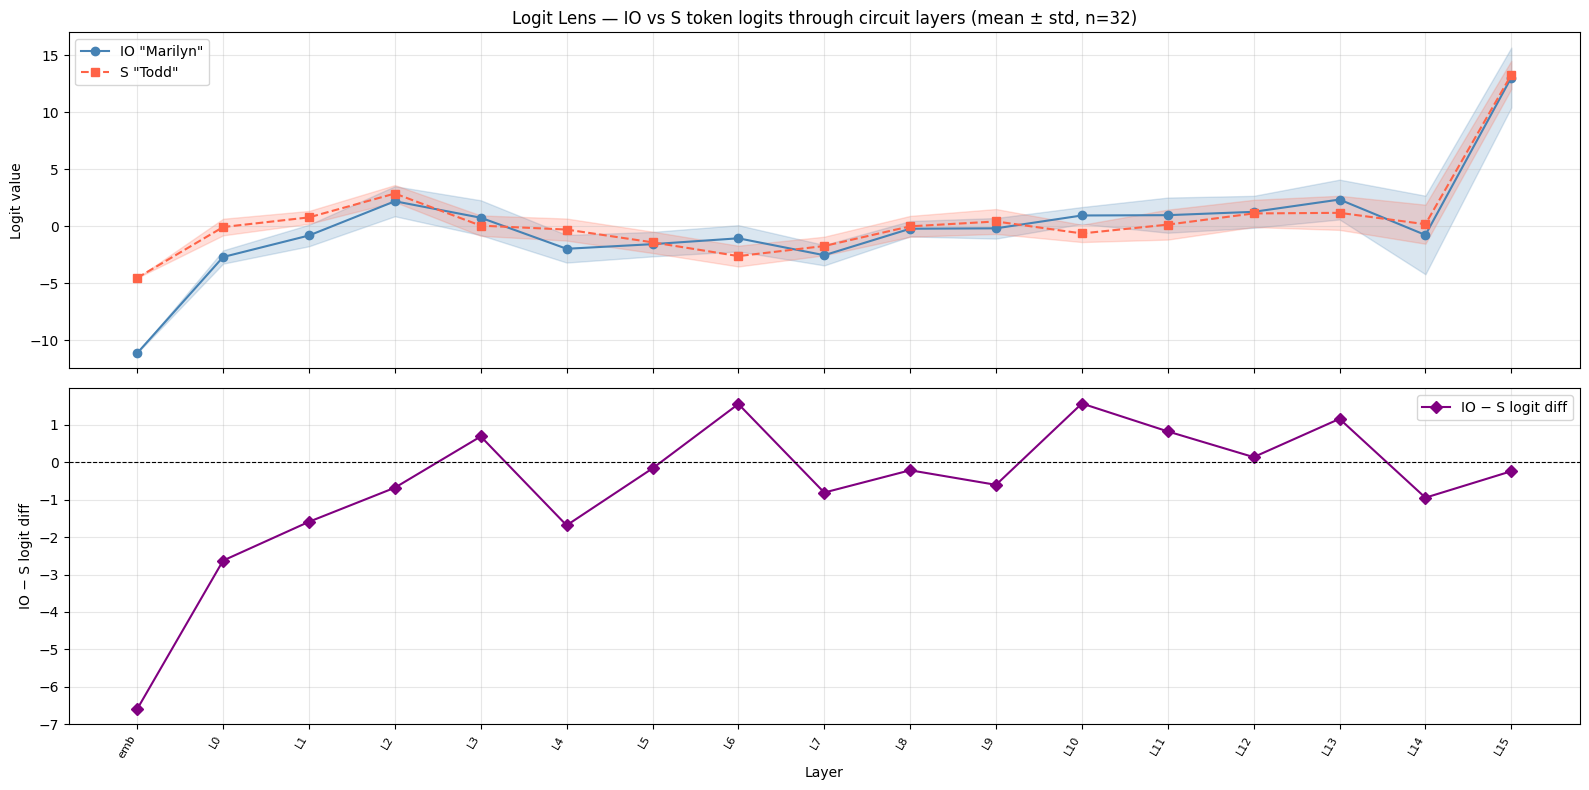

In [60]:
# Plot IO logit, S logit, and IO−S logit diff across layers (mean ± std over batch)
layers_sorted = sorted(_io_logits_per_layer.keys())
layer_labels  = ['emb' if l == -1 else f'L{l}' for l in layers_sorted]

io_mean = np.array([_io_logits_per_layer[l].mean().item() for l in layers_sorted])
s_mean  = np.array([_s_logits_per_layer[l].mean().item()  for l in layers_sorted])
io_std  = np.array([_io_logits_per_layer[l].std().item()  for l in layers_sorted])
s_std   = np.array([_s_logits_per_layer[l].std().item()   for l in layers_sorted])
diff    = io_mean - s_mean
x = np.arange(len(layer_labels))

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top panel: raw IO and S logits
axes[0].plot(x, io_mean, 'o-', color='steelblue', label=f'IO "{target_str}"')
axes[0].fill_between(x, io_mean - io_std, io_mean + io_std, color='steelblue', alpha=0.2)
axes[0].plot(x, s_mean, 's--', color='tomato', label=f'S "{distractor_str}"')
axes[0].fill_between(x, s_mean - s_std, s_mean + s_std, color='tomato', alpha=0.2)
axes[0].set_ylabel('Logit value')
axes[0].set_title(f'Logit Lens — IO vs S token logits through circuit layers (mean ± std, n={B_lens})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom panel: IO − S logit difference
axes[1].plot(x, diff, 'D-', color='purple', label='IO − S logit diff')
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_ylabel('IO − S logit diff')
axes[1].set_xlabel('Layer')
axes[1].set_xticks(x)
axes[1].set_xticklabels(layer_labels, rotation=60, ha='right', fontsize=8)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'posthoc_logit_lens.png'), dpi=150)
plt.show()


---
## Summary

All plots saved to `SAVE_DIR`:

| File | Content |
|------|---------|
| `posthoc_head_mask.png` | Surviving head heatmap |
| `posthoc_mlp_neurons.png` | MLP neuron survival per layer |
| `posthoc_attn_io_vs_s.png` | IO vs S attention per head |
| `posthoc_attn_pattern_L*H*.png` | Full attention heatmap with IO/S/pred markers |
| `posthoc_dla_heads.png` | DLA (IO−S) per surviving head |
| `posthoc_dla_mlp.png` | MLP DLA (IO−S) per layer |
| `posthoc_role_map.png` | Head role scatter (IO attention vs DLA) |
| `posthoc_ov_io_vs_s.png` | IO copy score vs S copy score per head |
| `posthoc_ablation.png` | Accuracy drop per ablated head |
| `posthoc_logit_lens.png` | Logit lens — IO/S token through layers |
| `posthoc_mlp_neuron_vocab_L*.png` | MLP neuron IO/S write-logit per layer |
| `posthoc_attn_neuron_L*H*.png` | Attention head neuron write direction |
| `posthoc_circuit_story.png` | **End-to-end circuit story (Section 9)** |
| `posthoc_head_summary.csv` | Full head table |


---
## Section 8 — Individual Neuron Analysis

What are the surviving neurons *actually doing*?  
We study three things:

| Analysis | What it reveals |
|----------|-----------------|
| **8.1 Vocab projection** | What each neuron *writes* to the residual stream — projected through W_U to vocabulary space |
| **8.2 Input sensitivity** | Which input tokens *activate* each neuron (gate path and up path in SwiGLU) |
| **8.3 Activation on test data** | When does the neuron fire — distribution across examples, correlation with IO−S logit diff |
| **8.4 Attention head neurons** | Same weight-space analysis for surviving head-dimension neurons (neuron_gates) |

**Llama SwiGLU notation:**
$$\text{neuron}_i(x) = \sigma_{\text{silu}}(\underbrace{W_\text{gate}[i,:] \cdot x}_{\text{gate path}}) \;\times\; \underbrace{W_\text{up}[i,:] \cdot x}_{\text{up path}}$$
$$\text{MLP output} = \sum_i W_\text{down}[:,i] \cdot \text{neuron}_i(x)$$

So $W_\text{down}[:,i]$ is the *writing direction* of neuron $i$.

In [23]:
import importlib
import posthoc_analysis.analysis_utils as _au
importlib.reload(_au)

from posthoc_analysis.analysis_utils import (
    get_mlp_neuron_vocab_projections,
    capture_mlp_neuron_activations,
    get_attn_neuron_vocab_projections,
    compute_neuron_io_correlation,
    capture_logit_diffs_batch,
)

# ---- Which layers to study ----
surv_neurons_all = get_surviving_mlp_neurons(circuit_model)
surv_attn_all    = get_surviving_heads(circuit_model)
n_layers         = len(circuit_model.model.layers)

mlp_ranked = sorted(
    [(l, len(surv_neurons_all[l][0])) for l in range(n_layers) if len(surv_neurons_all[l][0]) > 0],
    key=lambda x: -x[1]
)
NEURON_LAYERS = [l for l, _ in mlp_ranked[:2]] if mlp_ranked else [0]
TOP_N = 32   # number of high-activating neurons to keep per layer

# ---- Filter to high-activating subset by capturing actual activations ----
# We use the analysis_batch (already loaded); neurons that don't fire on real
# IOI examples at the prediction position are not interpretable anyway.
high_act_neurons = {}   # {layer: sorted list of neuron indices}

for LAYER in NEURON_LAYERS:
    all_surv = surv_neurons_all[LAYER][0].tolist()
    acts = capture_mlp_neuron_activations(
        circuit_model,
        analysis_batch['input_ids'],
        analysis_batch['attention_mask'],
        analysis_batch['corrupted_input_ids'],
        layer=LAYER,
        pred_positions=pred_pos,
        device=DEVICE,
    )   # (B, intermediate_size)

    # Mean absolute activation across examples, restricted to surviving neurons
    mean_act = acts[:, all_surv].abs().mean(0)    # (n_surv,)
    top_local = mean_act.topk(min(TOP_N, len(all_surv))).indices.tolist()
    top_global = [all_surv[i] for i in top_local]
    high_act_neurons[LAYER] = top_global

    print(f"L{LAYER}: {len(all_surv)} surviving → keeping top-{len(top_global)} by mean |activation|")
    print(f"  activation range kept: {mean_act[top_local[-1]]:.4f} – {mean_act[top_local[0]]:.4f}")
    print(f"  neurons: {top_global[:10]} ...")

L0: 5287 surviving → keeping top-32 by mean |activation|
  activation range kept: 0.0400 – 0.2754
  neurons: [7298, 4675, 1972, 3165, 6106, 4261, 5262, 1038, 7551, 4096] ...
L10: 2623 surviving → keeping top-32 by mean |activation|
  activation range kept: 0.1973 – 1.2344
  neurons: [2308, 1400, 4604, 1909, 1467, 6389, 7208, 3864, 7940, 5200] ...


### 8.1 Vocab projection — what does each neuron write?

For each surviving neuron $i$ we compute $W_U \cdot W_\text{down}[:,i]$ and report the top promoted / suppressed tokens.
A neuron that promotes name-like tokens is likely part of the IO-mover pathway; one that promotes "to"/"gave" is a syntactic neuron.

In [24]:
vocab_proj_all = {}   # {layer: {neuron_idx: dict}}

for LAYER in NEURON_LAYERS:
    neuron_subset = high_act_neurons[LAYER]
    print(f"\nLayer {LAYER}: vocab projections for {len(neuron_subset)} high-activating neurons ...")
    proj = get_mlp_neuron_vocab_projections(
        circuit_model, LAYER, neuron_subset, tokenizer, top_k=10
    )
    vocab_proj_all[LAYER] = proj

    # Sort by write-norm within this subset
    proj_sorted = sorted(proj.items(), key=lambda kv: -kv[1]["write_norm"])

    print(f"\n{'Neuron':>8}  {'Write‖':>8}  {'IO wl':>8}  {'S wl':>8}  {'IO−S':>7}  {'Top-3 promoted':28}  Top-3 suppressed")
    print("-" * 110)
    for idx, info in proj_sorted:
        prom = " | ".join(f'"{t}"' for t in info["top_promoted"][:3])
        supp = " | ".join(f'"{t}"' for t in info["top_suppressed"][:3])
        # IO/S-specific write-logit (mean over analysis batch)
        io_wl = torch.stack([
            info["write_logits"][target_ids[b].item()]
            for b in range(len(target_ids))
        ]).float().mean().item()
        s_wl  = torch.stack([
            info["write_logits"][distractor_ids[b].item()]
            for b in range(len(distractor_ids))
        ]).float().mean().item()
        print(f"  N{idx:>5d}  {info['write_norm']:>8.3f}  {io_wl:>+8.3f}  {s_wl:>+8.3f}  {io_wl-s_wl:>+7.3f}  {prom:28s}  {supp}")



Layer 0: vocab projections for 32 high-activating neurons ...


KeyboardInterrupt: 

In [25]:
# Heatmap: for the top-MAX_NEURONS neurons in each layer, show write-logit
# for the IO (target) and S (distractor) tokens of example 0.
for LAYER in NEURON_LAYERS:
    proj = vocab_proj_all[LAYER]
    surv_hid_idx = surv_neurons_all[LAYER][0].tolist()
    proj_sorted  = sorted(proj.items(), key=lambda kv: -kv[1]["write_norm"])
    plot_neurons = [idx for idx, _ in proj_sorted[:MAX_NEURONS]]

    # Gather IO/S write-logit for each neuron (averaged over analysis_batch examples)
    io_scores_n  = []
    s_scores_n   = []
    norms_n      = []

    for idx in plot_neurons:
        wl = proj[idx]["write_logits"]   # (vocab,)
        # Average across examples (target/distractor token may differ per example)
        io_w = torch.stack([wl[target_ids[b].item()]     for b in range(len(target_ids))]).mean().item()
        s_w  = torch.stack([wl[distractor_ids[b].item()] for b in range(len(distractor_ids))]).mean().item()
        io_scores_n.append(io_w)
        s_scores_n.append(s_w)
        norms_n.append(proj[idx]["write_norm"])

    diff_n = np.array(io_scores_n) - np.array(s_scores_n)

    # Sort by IO−S diff for the plot
    order = np.argsort(-diff_n)
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(plot_neurons)*0.18 + 1)))

    # Left: IO and S logit contribution side by side
    y = np.arange(len(plot_neurons))
    ax = axes[0]
    ax.barh(y, np.array(io_scores_n)[order], 0.4, label='IO write-logit', color='steelblue')
    ax.barh(y + 0.4, np.array(s_scores_n)[order],  0.4, label='S  write-logit', color='tomato')
    ax.set_yticks(y + 0.2)
    ax.set_yticklabels([f'N{plot_neurons[i]}' for i in order], fontsize=7)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Write-logit value')
    ax.set_title(f'L{LAYER} MLP neurons: IO vs S write-logit')
    ax.legend(fontsize=8)

    # Right: IO − S diff (the task-relevant signal)
    ax2 = axes[1]
    colors = ['steelblue' if v >= 0 else 'tomato' for v in diff_n[order]]
    ax2.barh(y, diff_n[order], color=colors)
    ax2.set_yticks(y)
    ax2.set_yticklabels([f'N{plot_neurons[i]}' for i in order], fontsize=7)
    ax2.axvline(0, color='black', linewidth=0.8)
    ax2.set_xlabel('IO write-logit − S write-logit')
    ax2.set_title(f'L{LAYER} MLP neurons: task-relevant write direction')

    plt.suptitle(f'Layer {LAYER} — MLP neuron vocab projections (top {len(plot_neurons)} by write-norm)', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'posthoc_mlp_neuron_vocab_L{LAYER}.png'), dpi=150)
    plt.show()

KeyError: 0

### 8.2 Input sensitivity — what activates each neuron?

`gate_proj[i, :] @ W_E[t, :]` tells you how much token $t$ (when embedded) drives the gate pathway of neuron $i$.
Neurons with high sensitivity to name-like tokens are *name detectors*; those sensitive to "gave"/"to" are *syntax detectors*.

In [26]:
for LAYER in NEURON_LAYERS:
    proj = vocab_proj_all[LAYER]
    proj_sorted = sorted(proj.items(), key=lambda kv: -kv[1]["write_norm"])
    top20 = proj_sorted[:20]

    # Pre-compute gate sensitivity vectors for IO/S tokens
    mlp_g = circuit_model.model.layers[LAYER].mlp.original_mlp
    W_g   = mlp_g.gate_proj.weight.detach().float().cpu()   # (intermediate, hidden)
    W_E_g = circuit_model.model.embed_tokens.weight.detach().float().cpu()  # (vocab, hidden)

    print(f"\n=== Layer {LAYER} — Input sensitivity for IO and S tokens (top 20 neurons by write-norm) ===")
    print(f"{'Neuron':>8}  {'IO gate':>9}  {'S gate':>9}  {'IO−S gate':>10}  {'IO wl':>8}  {'S wl':>8}  Top-4 gate activating")
    print("-" * 110)
    for idx, info in top20:
        # Gate sensitivity specifically for IO and S token embeddings (mean over batch)
        io_gate = torch.stack([
            W_g[idx] @ W_E_g[target_ids[b].item()]
            for b in range(len(target_ids))
        ]).mean().item()
        s_gate  = torch.stack([
            W_g[idx] @ W_E_g[distractor_ids[b].item()]
            for b in range(len(distractor_ids))
        ]).mean().item()
        io_wl = torch.stack([
            info["write_logits"][target_ids[b].item()]
            for b in range(len(target_ids))
        ]).float().mean().item()
        s_wl  = torch.stack([
            info["write_logits"][distractor_ids[b].item()]
            for b in range(len(distractor_ids))
        ]).float().mean().item()
        gate_str = " | ".join(f'"{t}"' for t in info["top_gate_activating"][:4])
        print(f"  N{idx:>5d}  {io_gate:>+9.3f}  {s_gate:>+9.3f}  {io_gate-s_gate:>+10.3f}  {io_wl:>+8.3f}  {s_wl:>+8.3f}  {gate_str}")

    print(f"\n  IO gate : how strongly the gate pathway is driven when IO token appears in input")
    print(f"  S gate  : how strongly the gate pathway is driven when S  token appears in input")
    print(f"  IO−S gate > 0 → neuron preferentially activates on IO token occurrences")


KeyError: 0

### 8.3 Activation on test data — when do neurons fire?

We capture each surviving neuron's actual activation at the prediction position on the test set and correlate it with the IO−S logit difference.  
- **High positive correlation** → neuron fires more when model is confident about IO (likely task-helpful)  
- **High negative correlation** → neuron fires more on wrong predictions (potentially task-harmful or confounding)

In [27]:
# Collect logit-diffs over the full test set (once)
print("Collecting IO−S logit diffs over test set ...")
logit_diffs_all, correct_all = capture_logit_diffs_batch(circuit_model, test_dataloader, DEVICE)
print(f"  Mean logit diff: {logit_diffs_all.mean():.3f}  |  Accuracy: {correct_all.float().mean():.3f}")

  Mean logit diff: 3.513  |  Accuracy: 0.425


In [28]:
for LAYER in NEURON_LAYERS:
    neuron_subset = high_act_neurons[LAYER]

    # Reuse activations already captured in the setup cell
    acts = capture_mlp_neuron_activations(
        circuit_model,
        analysis_batch['input_ids'],
        analysis_batch['attention_mask'],
        analysis_batch['corrupted_input_ids'],
        layer=LAYER,
        pred_positions=pred_pos,
        device=DEVICE,
    )   # (B, intermediate_size)
    acts_sub = acts[:, neuron_subset]   # (B, TOP_N)

    # IO−S logit diff for this batch
    with torch.no_grad():
        out = circuit_model(
            input_ids=analysis_batch['input_ids'].to(DEVICE),
            attention_mask=analysis_batch['attention_mask'].to(DEVICE),
            corrupted_input_ids=analysis_batch['corrupted_input_ids'].to(DEVICE),
        )
    logits = out.logits if hasattr(out, 'logits') else out[0]
    B = logits.shape[0]
    ld_batch = torch.stack([
        logits[b, pred_pos[b], target_ids[b]] - logits[b, pred_pos[b], distractor_ids[b]]
        for b in range(B)
    ]).cpu()

    corr = compute_neuron_io_correlation(acts_sub, ld_batch)   # (TOP_N,)
    mean_act = acts_sub.abs().mean(0)                          # (TOP_N,)
    surv_arr = np.array(neuron_subset)

    # Cast to float32 — numpy doesn't support bfloat16
    corr = corr.float()
    mean_act = mean_act.float()

    top_pos = corr.topk(min(10, len(corr))).indices.tolist()
    top_neg = corr.topk(min(10, len(corr)), largest=False).indices.tolist()

    print(f"\n=== Layer {LAYER} — top IO-correlated neurons (fire more when model is right) ===")
    for si in top_pos:
        info = vocab_proj_all[LAYER].get(surv_arr[si], {})
        print(f"  N{surv_arr[si]:5d}  corr={corr[si]:+.3f}  act={mean_act[si]:.3f}  writes: {info.get('top_promoted',[])[:3]}")

    print(f"\n=== Layer {LAYER} — top anti-correlated neurons (fire more when model is wrong) ===")
    for si in top_neg:
        info = vocab_proj_all[LAYER].get(surv_arr[si], {})
        print(f"  N{surv_arr[si]:5d}  corr={corr[si]:+.3f}  act={mean_act[si]:.3f}  writes: {info.get('top_promoted',[])[:3]}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(corr.numpy(), bins=20, color='steelblue', edgecolor='white')
    axes[0].axvline(0, color='black', lw=0.8)
    axes[0].set_xlabel('Pearson r  (neuron activation vs IO−S logit diff)')
    axes[0].set_ylabel('# neurons')
    axes[0].set_title(f'L{LAYER} neuron–task correlation (top-{TOP_N} active neurons)')

    sc = axes[1].scatter(mean_act.numpy(), corr.numpy(),
                         c=corr.numpy(), cmap='RdBu', s=50,
                         vmin=-corr.abs().max().item(), vmax=corr.abs().max().item())
    for si in top_pos + top_neg:
        axes[1].annotate(f'N{surv_arr[si]}', (mean_act[si].item(), corr[si].item()), fontsize=7)
    axes[1].axhline(0, color='black', lw=0.8)
    plt.colorbar(sc, ax=axes[1], label='correlation')
    axes[1].set_xlabel('Mean |activation|')
    axes[1].set_ylabel('Correlation with IO−S logit diff')
    axes[1].set_title(f'L{LAYER} activation strength vs task relevance')

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'posthoc_neuron_activation_L{LAYER}.png'), dpi=150)
    plt.show()



=== Layer 0 — top IO-correlated neurons (fire more when model is right) ===


KeyError: 0

### 8.4 Attention head neurons (dimension-level)

The `neuron_gates` inside each attention head control individual dimensions of the head's value output.
For each surviving head we project its surviving dimensions through $W_U$ to see what each dimension *writes* to the residual stream.

In [29]:
head_dim = circuit_model.config.hidden_size // circuit_model.config.num_attention_heads

for (l, h) in surv_head_list[:6]:   # first 6 surviving heads; adjust as needed
    # Find surviving dimensions for this head from neuron_gates
    attn_mod = circuit_model.model.layers[l].attn
    if attn_mod.neuron_gates is None:
        # No neuron-level pruning — all dims survive
        surv_dims = list(range(head_dim))
    else:
        with torch.no_grad():
            ng = attn_mod.neuron_gates()    # (num_heads * head_dim,)
        # Extract dims for this head
        ng_head = ng[h * head_dim : (h + 1) * head_dim]
        surv_dims = (ng_head > 0.5).nonzero(as_tuple=True)[0].tolist()

    if not surv_dims:
        print(f"L{l}H{h}: no surviving neuron dims (block-level only)")
        continue

    print(f"\nL{l}H{h}: {len(surv_dims)}/{head_dim} dims survive")
    dn_proj = get_attn_neuron_vocab_projections(
        circuit_model, l, h, surv_dims, tokenizer, top_k=8
    )

    # Sort dims by write_norm
    dn_sorted = sorted(dn_proj.items(), key=lambda kv: -kv[1]["write_norm"])

    print(f"  {'Dim':>5}  {'Write‖':>7}  {'Top-3 promoted':28}  Top-3 suppressed")
    print("  " + "-" * 75)
    for d, info in dn_sorted[:15]:
        prom = " | ".join(f'"{t}"' for t in info["top_promoted"][:3])
        supp = " | ".join(f'"{t}"' for t in info["top_suppressed"][:3])
        print(f"  D{d:>4d}  {info['write_norm']:>7.3f}  {prom:28s}  {supp}")

    # Scatter: write_norm vs IO−S write-logit for each dim
    io_dn  = [dn_proj[d]["write_logits"][target_ids[0].item()].item() for d in surv_dims]
    s_dn   = [dn_proj[d]["write_logits"][distractor_ids[0].item()].item() for d in surv_dims]
    norms  = [dn_proj[d]["write_norm"] for d in surv_dims]
    diff_dn = np.array(io_dn) - np.array(s_dn)

    fig, ax = plt.subplots(figsize=(6, 4))
    sc = ax.scatter(norms, diff_dn, c=diff_dn, cmap='RdBu', s=40, vmin=-max(abs(diff_dn))-1e-9, vmax=max(abs(diff_dn))+1e-9)
    for i, d in enumerate(surv_dims):
        if abs(diff_dn[i]) > np.percentile(abs(diff_dn), 80):
            ax.annotate(f'D{d}', (norms[i], diff_dn[i]), fontsize=7)
    ax.axhline(0, color='black', linewidth=0.8)
    plt.colorbar(sc, ax=ax, label='IO−S write-logit')
    ax.set_xlabel('Write norm')
    ax.set_ylabel('IO write-logit − S write-logit')
    ax.set_title(f'L{l}H{h} attention neurons — write direction analysis')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'posthoc_attn_neuron_L{l}H{h}.png'), dpi=150)
    plt.show()


L8H17: 50/64 dims survive


KeyboardInterrupt: 

---
## Section 9 — End-to-End Circuit Story: IO Token vs S Token

This section synthesizes every analysis above into a single narrative:  
**How does the pruned circuit identify the IO token and suppress the S token?**

### The task
Given a sentence like:  
> *"John and Mary went to the store. John gave a book to ___"*

The model must output **"Mary"** (the IO token = the person who did **not** repeat)  
and suppress **"John"** (the S token = the repeated subject).

### The three-stage mechanism (Wang et al. 2022, adapted)

| Stage | Layer range | What happens | IO effect | S effect |
|-------|-------------|--------------|-----------|----------|
| **1. Duplicate-token detection** | Early | Certain heads attend from one S-occurrence to the other. They build a "this-token-appeared-before" signal. | neutral | S gets flagged |
| **2. S-Inhibition** | Mid | S-Inhibitor heads attend to S-name positions. Their OV output *suppresses* the S logit at the prediction position. | neutral | S logit drops |
| **3. IO-Mover / Name-Mover** | Late | IO-Mover heads attend strongly to IO-name position. Their OV output *copies* the IO token into the prediction logit. | IO logit rises | neutral |

### Reading the visualization below

- **Panel 1 — Head role timeline**: each surviving head is plotted at its layer. Color = role (blue=IO-Mover, red=S-Inhibitor, grey=Other). Bubble size = |DLA (IO−S)| importance. Vertical arrows show the flow of information through stages.  
- **Panel 2 — Cumulative DLA**: how much IO-advantage (`DLA_IO − DLA_S`) each layer's components contribute, stacked to show where the decision builds up.  
- **Panel 3 — Logit lens**: the running IO and S logit values as the residual stream passes through each layer, showing exactly *when* the model commits to IO over S.


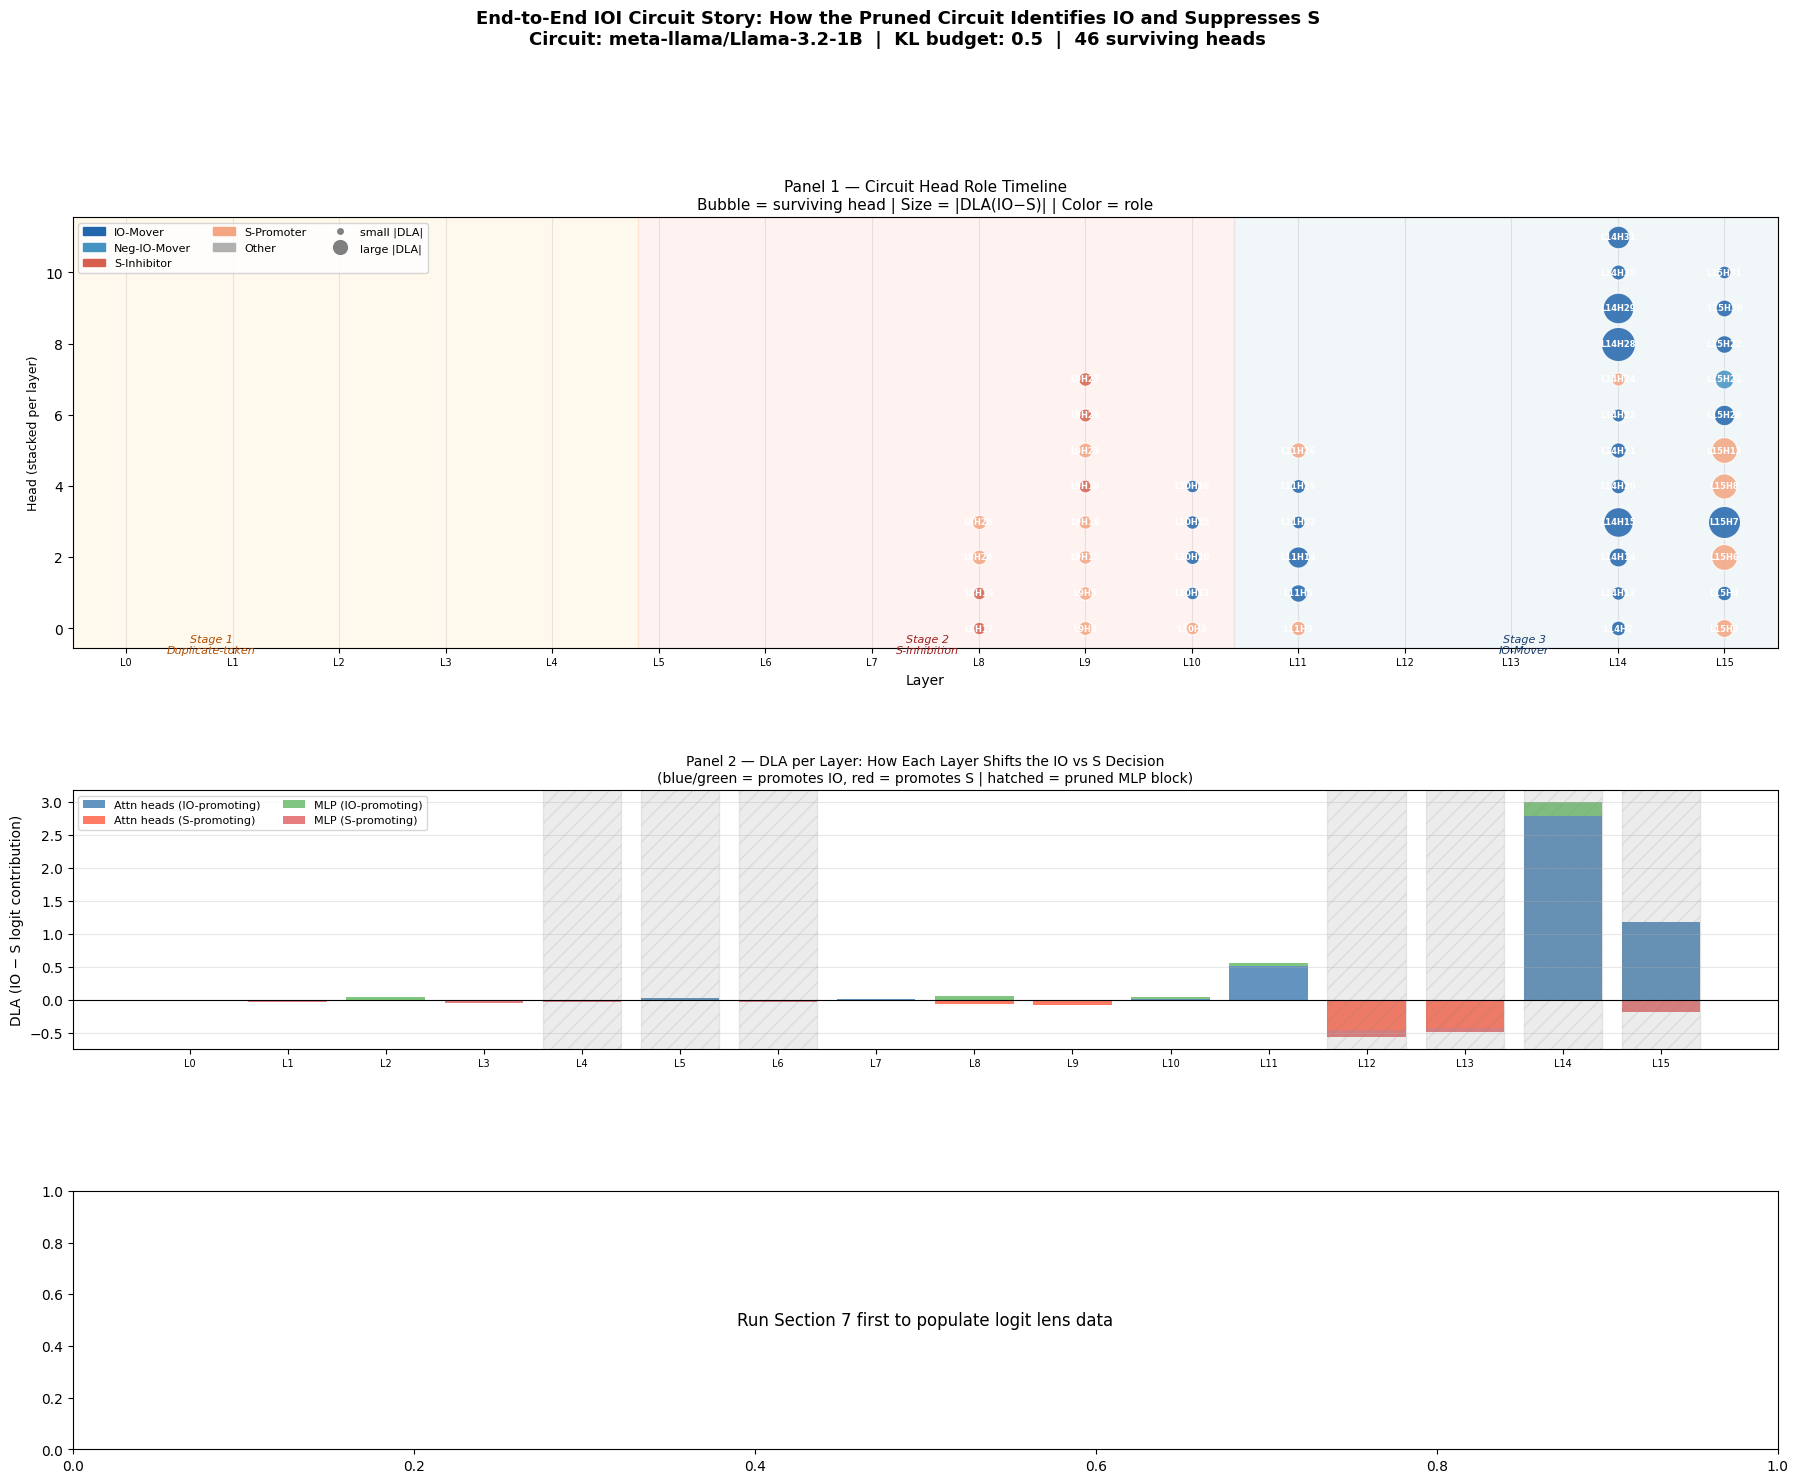


Saved -> /home/exouser/circuit_pruning/results/ioi_kl_budget_final_1B_with_blocks_0.5kl_no_task_loss/posthoc_circuit_story.png


In [30]:
# ── Section 9 · End-to-End IOI Circuit Story ──────────────────────────────
# Requires: role_df, head_dla_diff, mlp_dla_diff, _io_logits_per_layer,
#           _s_logits_per_layer, surv_head_list  (all computed in sections 3-7)

ROLE_COLOR = {
    'IO-Mover':     '#2166ac',
    'Neg-IO-Mover': '#4393c3',
    'S-Inhibitor':  '#d6604d',
    'S-Promoter':   '#f4a582',
    'Other':        '#b0b0b0',
}

n_layers = len(circuit_model.model.layers)

# ── Panel layout ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 16))
gs  = fig.add_gridspec(3, 1, hspace=0.45, height_ratios=[2.5, 1.5, 1.5])
ax1 = fig.add_subplot(gs[0])   # head role timeline
ax2 = fig.add_subplot(gs[1])   # cumulative DLA
ax3 = fig.add_subplot(gs[2])   # logit lens IO vs S

# ── PANEL 1 — Head role timeline ──────────────────────────────────────────
# y-jitter so overlapping heads in the same layer are visible
import random
random.seed(42)
_y_offset_counter = {}

for _, row in role_df.iterrows():
    l = row['layer']
    role = row['role']
    dla  = abs(row['io_dla_minus_s_dla'])
    color = ROLE_COLOR.get(role, '#b0b0b0')

    # Stack heads vertically within same layer
    _y_offset_counter[l] = _y_offset_counter.get(l, 0)
    y_pos = _y_offset_counter[l]
    _y_offset_counter[l] += 1

    size = max(80, min(800, dla * 1200 + 80))
    ax1.scatter(l, y_pos, s=size, color=color, alpha=0.85, zorder=3,
                edgecolors='white', linewidths=0.8)
    ax1.annotate(row['label'], (l, y_pos), ha='center', va='center',
                 fontsize=6, color='white', fontweight='bold', zorder=4)

# Legend patches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_patches = [Patch(color=c, label=r) for r, c in ROLE_COLOR.items() if r != 'Neg-IO-Mover' or True]
size_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markersize=ms, label=lbl)
    for ms, lbl in [(6, 'small |DLA|'), (12, 'large |DLA|')]
]
ax1.legend(handles=legend_patches + size_legend, loc='upper left', fontsize=8, ncol=3)

# Stage annotation bands
stage_alpha = 0.07
ax1.axvspan(-0.5, n_layers * 0.30, color='orange',    alpha=stage_alpha, label='Stage 1: Duplicate-token')
ax1.axvspan(n_layers * 0.30, n_layers * 0.65, color='tomato', alpha=stage_alpha, label='Stage 2: S-Inhibition')
ax1.axvspan(n_layers * 0.65, n_layers - 0.5, color='steelblue', alpha=stage_alpha, label='Stage 3: IO-Mover')
ax1.text(n_layers * 0.05, -0.7, 'Stage 1\nDuplicate-token', color='#b05000', fontsize=8, ha='center', style='italic')
ax1.text(n_layers * 0.47, -0.7, 'Stage 2\nS-Inhibition',   color='#a02020', fontsize=8, ha='center', style='italic')
ax1.text(n_layers * 0.82, -0.7, 'Stage 3\nIO-Mover',       color='#1a3c6e', fontsize=8, ha='center', style='italic')

ax1.set_xlim(-0.5, n_layers - 0.5)
ax1.set_xlabel('Layer', fontsize=10)
ax1.set_ylabel('Head (stacked per layer)', fontsize=9)
ax1.set_title('Panel 1 — Circuit Head Role Timeline\n'
              'Bubble = surviving head | Size = |DLA(IO−S)| | Color = role', fontsize=11)
ax1.set_xticks(range(n_layers))
ax1.set_xticklabels([f'L{l}' for l in range(n_layers)], fontsize=7)
ax1.grid(axis='x', alpha=0.3)

# ── PANEL 2 — Cumulative DLA per layer ────────────────────────────────────
# Per-layer DLA contribution (sum over heads in that layer + MLP)
layer_attn_dla = {}
for (l, h), val in head_dla_diff.items():
    if l not in layer_attn_dla:
        layer_attn_dla[l] = 0.0
    layer_attn_dla[l] += val

layers_all = list(range(n_layers))
attn_vals  = [layer_attn_dla.get(l, 0.0) for l in layers_all]
mlp_vals   = [mlp_dla_diff.get(l, 0.0)   for l in layers_all]

# Separate positive and negative for stacked bar
attn_pos = [max(0, v) for v in attn_vals]
attn_neg = [min(0, v) for v in attn_vals]
mlp_pos  = [max(0, v) for v in mlp_vals]
mlp_neg  = [min(0, v) for v in mlp_vals]

x2 = np.arange(n_layers)
ax2.bar(x2, attn_pos, color='steelblue', alpha=0.85, label='Attn heads (IO-promoting)')
ax2.bar(x2, attn_neg, color='tomato',    alpha=0.85, label='Attn heads (S-promoting)')
ax2.bar(x2, mlp_pos,  color='#2ca02c',  alpha=0.6,  label='MLP (IO-promoting)',  bottom=attn_pos)
ax2.bar(x2, mlp_neg,  color='#d62728',  alpha=0.6,  label='MLP (S-promoting)',   bottom=attn_neg)
ax2.axhline(0, color='black', linewidth=0.8)

# Mark pruned MLP blocks
surv_mlp_blks = get_surviving_mlp_blocks(circuit_model)
for l in layers_all:
    if not surv_mlp_blks.get(l, True):
        ax2.axvspan(l - 0.4, l + 0.4, color='grey', alpha=0.15, hatch='//')

ax2.set_xticks(x2)
ax2.set_xticklabels([f'L{l}' for l in layers_all], fontsize=7)
ax2.set_ylabel('DLA (IO − S logit contribution)')
ax2.set_title('Panel 2 — DLA per Layer: How Each Layer Shifts the IO vs S Decision\n'
              '(blue/green = promotes IO, red = promotes S | hatched = pruned MLP block)', fontsize=10)
ax2.legend(fontsize=8, ncol=2)
ax2.grid(axis='y', alpha=0.3)

# ── PANEL 3 — Logit lens IO vs S ──────────────────────────────────────────
if '_io_logits_per_layer' in dir() or '_io_logits_per_layer' in globals():
    layers_sorted = sorted(_io_logits_per_layer.keys())
    layer_labels  = ['emb' if l == -1 else f'L{l}' for l in layers_sorted]
    x3 = np.arange(len(layer_labels))

    io_mean = np.array([_io_logits_per_layer[l].mean().item() for l in layers_sorted])
    s_mean  = np.array([_s_logits_per_layer[l].mean().item()  for l in layers_sorted])
    io_std  = np.array([_io_logits_per_layer[l].std().item()  for l in layers_sorted])
    s_std   = np.array([_s_logits_per_layer[l].std().item()   for l in layers_sorted])

    ax3.plot(x3, io_mean, 'o-', color='steelblue', linewidth=2, label=f'IO "{target_str}" logit')
    ax3.fill_between(x3, io_mean - io_std, io_mean + io_std, color='steelblue', alpha=0.15)
    ax3.plot(x3, s_mean,  's--', color='tomato',    linewidth=2, label=f'S  "{distractor_str}" logit')
    ax3.fill_between(x3, s_mean - s_std,  s_mean + s_std,  color='tomato',    alpha=0.15)

    # Shade the region where IO > S
    ax3.fill_between(x3, io_mean, s_mean,
                     where=(io_mean > s_mean), color='steelblue', alpha=0.10, label='IO > S region')
    ax3.fill_between(x3, io_mean, s_mean,
                     where=(io_mean < s_mean), color='tomato',    alpha=0.10, label='S > IO region')

    ax3.axhline(0, color='black', linewidth=0.5, linestyle=':')
    ax3.set_xticks(x3)
    ax3.set_xticklabels(layer_labels, rotation=60, ha='right', fontsize=7)
    ax3.set_ylabel('Logit value (mean ± std)')
    ax3.set_title(f'Panel 3 — Logit Lens: IO vs S Token Through Every Layer\n'
                  f'(n={len(_io_logits_per_layer[layers_sorted[0]])}, shaded = dominant token region)', fontsize=10)
    ax3.legend(fontsize=8, ncol=2)
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Run Section 7 first to populate logit lens data',
             ha='center', va='center', transform=ax3.transAxes, fontsize=12)

plt.suptitle(
    'End-to-End IOI Circuit Story: How the Pruned Circuit Identifies IO and Suppresses S\n'
    f'Circuit: {run_config["model"]}  |  KL budget: {run_config["kl_budget"]}  |  '
    f'{len(surv_head_list)} surviving heads',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig(os.path.join(SAVE_DIR, 'posthoc_circuit_story.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved -> {SAVE_DIR}/posthoc_circuit_story.png')


In [64]:
# ── Section 9 · Printed narrative summary ────────────────────────────────
print("=" * 72)
print("  END-TO-END IOI CIRCUIT NARRATIVE")
print("=" * 72)

eg_sent = tokenizer.decode(analysis_batch['input_ids'][0].tolist(), skip_special_tokens=True)
io_name  = target_str
s_name   = distractor_str
print(f"\nExample sentence (example 0):")
print(f"  {eg_sent[:120]}...")
print(f"\n  IO token (answer) : '{io_name}'")
print(f"  S  token (distract): '{s_name}'")

# Stage 1: identify any heads whose role_df marks them as attending more to S than IO
# AND whose layer is in the early third → potential duplicate-token heads
if not role_df.empty:
    early_cutoff = int(n_layers * 0.30)
    mid_cutoff   = int(n_layers * 0.65)

    early_heads = role_df[role_df['layer'] < early_cutoff].sort_values('s_attn', ascending=False)
    mid_heads   = role_df[(role_df['layer'] >= early_cutoff) & (role_df['layer'] < mid_cutoff) & (role_df['role'] == 'S-Inhibitor')]
    late_heads  = role_df[(role_df['layer'] >= mid_cutoff) & (role_df['role'] == 'IO-Mover')]

    print(f"\n{'─'*60}")
    print(f"STAGE 1 · Early layers (L0–L{early_cutoff-1}): Duplicate-token detection")
    print(f"{'─'*60}")
    if not early_heads.empty:
        for _, r in early_heads.head(5).iterrows():
            print(f"  {r['label']:8s}  io_attn={r['io_attn']:.3f}  s_attn={r['s_attn']:.3f}  "
                  f"DLA(IO−S)={r['io_dla_minus_s_dla']:+.3f}  role={r['role']}")
        print(f"  → These early heads preferentially attend to S-name positions, building")
        print(f"    a 'this name appeared before' signal that flags '{s_name}' as the repeated token.")
    else:
        print("  (no surviving heads in early layers)")

    print(f"\n{'─'*60}")
    print(f"STAGE 2 · Mid layers (L{early_cutoff}–L{mid_cutoff-1}): S-Inhibition")
    print(f"{'─'*60}")
    if not mid_heads.empty:
        for _, r in mid_heads.iterrows():
            ov_row = ov_df[ov_df['label'] == r['label']]
            s_copy = ov_row['s_copy_score'].values[0] if not ov_row.empty else float('nan')
            print(f"  {r['label']:8s}  s_attn={r['s_attn']:.3f}  DLA(IO−S)={r['io_dla_minus_s_dla']:+.3f}  "
                  f"OV s_copy={s_copy:+.3f}")
        print(f"  → S-Inhibitor heads attend to '{s_name}' (S-name positions) and, via their")
        print(f"    OV matrix, write a direction that suppresses the S logit at the output.")
        print(f"    (negative s_copy_score confirms: attending to S → output hurts S logit)")
    else:
        print("  (no S-Inhibitor heads classified in mid layers — may overlap with stage 3)")

    print(f"\n{'─'*60}")
    print(f"STAGE 3 · Late layers (L{mid_cutoff}–L{n_layers-1}): IO-Mover / Name-Mover")
    print(f"{'─'*60}")
    if not late_heads.empty:
        for _, r in late_heads.iterrows():
            ov_row = ov_df[ov_df['label'] == r['label']]
            io_copy = ov_row['io_copy_score'].values[0] if not ov_row.empty else float('nan')
            print(f"  {r['label']:8s}  io_attn={r['io_attn']:.3f}  DLA(IO−S)={r['io_dla_minus_s_dla']:+.3f}  "
                  f"OV io_copy={io_copy:+.3f}")
        print(f"  → IO-Mover heads attend strongly to '{io_name}' (IO-name position) and copy")
        print(f"    its identity into the output logit via their OV matrix.")
        print(f"    (positive io_copy_score confirms: attending to IO → output boosts IO logit)")
    else:
        print("  (no IO-Mover heads classified in late layers — check role thresholds)")

    # Final tally
    n_io_movers   = (role_df['role'] == 'IO-Mover').sum()
    n_s_inhibitors = (role_df['role'] == 'S-Inhibitor').sum()
    n_other       = (role_df['role'] == 'Other').sum()
    final_io_logit = _io_logits_per_layer[max(_io_logits_per_layer.keys())].mean().item()
    final_s_logit  = _s_logits_per_layer[max(_s_logits_per_layer.keys())].mean().item()

    print(f"\n{'='*60}")
    print(f"  CIRCUIT SUMMARY")
    print(f"{'='*60}")
    print(f"  IO-Mover heads   : {n_io_movers}")
    print(f"  S-Inhibitor heads: {n_s_inhibitors}")
    print(f"  Other heads      : {n_other}")
    print(f"  Final IO logit   : {final_io_logit:+.3f}")
    print(f"  Final S  logit   : {final_s_logit:+.3f}")
    print(f"  Final IO − S     : {final_io_logit - final_s_logit:+.3f}  "
          f"({'CORRECT: model picks IO' if final_io_logit > final_s_logit else 'INCORRECT: model picks S'})")


  END-TO-END IOI CIRCUIT NARRATIVE

Example sentence (example 0):
  Friends Chelsea and Gordon found a phone at the zoo. Chelsea gave it to Gordon...

  IO token (answer) : 'Marilyn'
  S  token (distract): 'Todd'

────────────────────────────────────────────────────────────
STAGE 1 · Early layers (L0–L3): Duplicate-token detection
────────────────────────────────────────────────────────────
  (no surviving heads in early layers)

────────────────────────────────────────────────────────────
STAGE 2 · Mid layers (L4–L9): S-Inhibition
────────────────────────────────────────────────────────────
  L8H17     s_attn=0.001  DLA(IO−S)=-0.003  OV s_copy=+0.003
  L8H19     s_attn=0.000  DLA(IO−S)=-0.006  OV s_copy=+0.002
  L9H5      s_attn=0.276  DLA(IO−S)=+0.003  OV s_copy=+nan
  L9H18     s_attn=0.540  DLA(IO−S)=-0.004  OV s_copy=-0.001
  L9H27     s_attn=0.353  DLA(IO−S)=+0.024  OV s_copy=-0.007
  → S-Inhibitor heads attend to 'Todd' (S-name positions) and, via their
    OV matrix, write a di